# 🏦 Stock Price Predictions

This project analyzes 5 stock prices over time to build predictive models that can apply 3 distinct modelling paradigms: time-series forecasting, survival analysis, and ranking.

## 0. Project Overview

**Analyzing historical data in 16 years of stock market data to predict stock price movements of five major tech firms** in the U.S.:
- Included stocks: 
    1. Apple (AAPL), 
    2. Microsoft (MSFT), 
    3. Amazon (AMZN), 
    4. Google (GOOGL), 
    5. Meta (META)

- 🗓️ Temporal Coverage: **2010 to 2026**
    - All trading days between January 1, 2010 to March 21, 2026

- Data Source: Yahoo Finance `yfinance` API


### 🎯 Objectives:
1. **Time-series forecasting** to predict future asset behavior
    - Test different types of forecasting models
    - Using the best model, forecast next month's stock prices for all 5 equities
2. **Survival Analysis** to model the time until significant price movement occurs.
    - Determine amount of days until ≥5% daily increase in stock price
3. **Asset Ranking** to list which assets to prioritize
    - Rank the 5 stocks according to possible daily gains <br>
        a. Rank based on all historical data<br>
        b. Rank based on possible gains this year

### Key Findings:
1. Time-Series Forecasting
    - Out of 4 different types of models, **ARIMA performs best for 4/5 stocks** and is less biased 3/5 times than the **2nd best performer, LGBM.**
    - ARIMA's predicted close prices on the next day, March 23, are around -0.30% off and no more than -2.17% off.
2. Survival Analysis
    - The Cox Proportional Hazards model can effectively distinguish between shorter and longer time for 5% return increase events.  
    - Its Concordance Indices are up to the ~0.80 range which are closer to 1.0 indicating strong ranking performance. 
    - Stocks with higher volatilty tend to experience 5% increase in returns sooner as seen with META (only 17 days until event)
    - Event timing for stable stocks like MSFT, GOOGL, and AAPL having the strongest signals and C-indices. 
3. Ranking
    - NDCG per year per ticker sits at around the ~0.80 mark
    - LGB with lambdarank pairwise shows good ranking potential for long-term ranking & top asset selection based on daily gains
    - Predicted ranking of the 5 stocks this year 2026 are close together and is as follows:
    1. META
    2. MSFT
    3. AAPL
    4. AMZN
    5. GOOGL

### Importing

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from helper import *
from matplotlib.gridspec import GridSpec
from matplotlib.collections import PolyCollection, LineCollection

import warnings
from itertools import combinations

import lightgbm as lgb
import scipy.stats as stats
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index
from lightgbm import LGBMRegressor
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

sns.set_style("darkgrid")
sns.set_theme(
    "notebook",
    rc={
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    },
)
sns.set_palette(["green"])

📌 Cut-off: The end date of this project will have a cut-off for consistent and repeatable results to be able to observe model performance over a fixed date.

**Cut-off date: March 21, 2026**

In [2]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]
start_date = "2010-01-01"
end_date = "2026-03-21"

📌 Saved data: The **yfinance data was downloaded directly from the API**  and **then saved unto a CSV** and frozen for deterministic values since the server returns slightly different values upon each request.

Data downloaded on: March 31, 2026

*If the user wishes to gather more data, adjust the dates, or update the csv: use this following block:*

In [ ]:
# df_load = yf.download(
#     tickers, start=start_date, end=end_date, interval="1d", auto_adjust=True
# )
# df_load.to_csv("dataset/stock_data.csv")

Loading saved data:

In [4]:
df_import = pd.read_csv(
    "dataset/stock_data.csv", header=[0, 1], index_col=0, parse_dates=True
)
df_import.columns = pd.MultiIndex.from_tuples(df_import.columns)
df_import.columns.names = [None, "Ticker"]
df_import.index.name = "Date"
df = df_import.copy()
df.head()

Close                                         High          \
Ticker          AAPL    AMZN      GOOGL META       MSFT      AAPL    AMZN   
Date                                                                        
2010-01-04  6.412382  6.6950  15.555863  NaN  23.077383  6.427063  6.8305   
2010-01-05  6.423470  6.7345  15.487361  NaN  23.084831  6.459725  6.7740   
2010-01-06  6.321295  6.6125  15.096945  NaN  22.943161  6.448938  6.7365   
2010-01-07  6.309609  6.5000  14.745496  NaN  22.704563  6.352157  6.6160   
2010-01-08  6.351559  6.6760  14.942069  NaN  22.861149  6.352159  6.6840   

                                       ...      Open                          \
Ticker          GOOGL META       MSFT  ...      AAPL    AMZN      GOOGL META   
Date                                   ...                                     
2010-01-04  15.624367  NaN  23.189228  ...  6.395003  6.8125  15.560827  NaN   
2010-01-05  15.582918  NaN  23.189221  ...  6.430062  6.6715  15.566537  NaN   
2010-01-06  15.533775  NaN  23.174307  ...  6.423469  6.7300  15.533775  NaN   
2010-01-07  15.140133  NaN  22.890972  ...  6.344666  6.6005  15.125240  NaN   
2010-01-08  14.972597  NaN  23.025188  ...  6.301221  6.5280  14.693373  NaN   

                          Volume                                       
Ticker           MSFT       AAPL       AMZN      GOOGL META      MSFT  
Date                                                                   
2010-01-04  22.831324  493729600  151998000   78169752  NaN  38409100  
2010-01-05  23.002812  601904800  177038000  120067812  NaN  49749600  
2010-01-06  23.025180  552160000  143576000  158988852  NaN  58182400  
2010-01-07  22.838776  477131200  220604000  256315428  NaN  50559700  
2010-01-08  22.577808  447610800  196610000  188783028  NaN  51197400  

[5 rows x 25 columns]

## 1. Data Cleaning

In [5]:
df.shape

(4078, 25)

Working with 4,078 points of data, meaning **4,078 trading days**.

### Data Types

For time series forecasting and other financial modelling processes, it is best if our **Index is in datetime format.**

In [6]:
print("Index data type: ", df.index.dtype)
print("Other Data Types: \n", df.dtypes)

Index data type:  datetime64[ns]
Other Data Types: 
         Ticker
Close   AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
High    AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
Low     AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
Open    AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
Volume  AAPL        int64
        AMZN        int64
        GOOGL       int64
        META      float64
        MSFT        int64
dtype: object


Minor fix: Uniform all Volume int features to float

In [7]:
df = df.astype(float)
df["Volume"].dtypes

Ticker
AAPL     float64
AMZN     float64
GOOGL    float64
META     float64
MSFT     float64
dtype: object

#### Null Values & Duplicates

In [8]:
df.isna().sum()

        Ticker
Close   AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
High    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Low     AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Open    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Volume  AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
dtype: int64

In [9]:
df["Volume"]["META"].first_valid_index()

Timestamp('2012-05-18 00:00:00')

The null values stem from Meta stocks beginning ~2 years later, missing 599 trading days. Meta went public on the stock market with its Initial Public Offering (IPO) on May 18, 2012. 

When modelling META, its null dates will be dropped.

In [10]:
df.duplicated().sum()

np.int64(0)

✅ There are no duplicates present.

### 🔧 Feature Engineering

Adding 2 new informational features:
1. Daily Returns (Log): analyzing percentage log change return of stocks in a day
2. Monthly Volatility: Measure of uncertainty about the returns provided by the stock. Rolled over 21 days.

In [11]:
log_ret = np.log(df["Close"] / df["Close"].shift(1))
log_ret.columns = pd.MultiIndex.from_product([["Return"], log_ret.columns])

# monthly volatility 21 day rolling
monthly_vol = log_ret["Return"].rolling(21).std()
monthly_vol.columns = pd.MultiIndex.from_product([["Volatility"], monthly_vol.columns])

df = pd.concat([df, log_ret, monthly_vol], axis=1)
df = df.sort_index(axis=1)
df[["Return", "Volatility"]].tail()

Return                                         Volatility  \
Ticker          AAPL      AMZN     GOOGL      META      MSFT       AAPL   
Date                                                                      
2026-03-16  0.010737  0.019409  0.010792  0.022997  0.011062   0.015631   
2026-03-17  0.005562  0.016209  0.017390 -0.007663 -0.001351   0.014906   
2026-03-18 -0.017018 -0.025080 -0.010443 -0.011273 -0.019262   0.013459   
2026-03-19 -0.003929 -0.005303 -0.001822 -0.014693 -0.007095   0.013424   
2026-03-20 -0.003904 -0.016372 -0.020161 -0.021728 -0.018551   0.013167   

                                                    
Ticker          AMZN     GOOGL      META      MSFT  
Date                                                
2026-03-16  0.016084  0.014433  0.017345  0.013942  
2026-03-17  0.016258  0.014740  0.017112  0.013942  
2026-03-18  0.017306  0.014668  0.017250  0.014368  
2026-03-19  0.016978  0.014658  0.017372  0.014332  
2026-03-20  0.017392  0.015343  0.017807  0.014823

Note: There are now nulls in the first Return (no previous day to compare) & Volatility (need 1st 21 days of data) rows that will be dropped upon modelling

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4078 entries, 2010-01-04 to 2026-03-20
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, AAPL)        4078 non-null   float64
 1   (Close, AMZN)        4078 non-null   float64
 2   (Close, GOOGL)       4078 non-null   float64
 3   (Close, META)        3479 non-null   float64
 4   (Close, MSFT)        4078 non-null   float64
 5   (High, AAPL)         4078 non-null   float64
 6   (High, AMZN)         4078 non-null   float64
 7   (High, GOOGL)        4078 non-null   float64
 8   (High, META)         3479 non-null   float64
 9   (High, MSFT)         4078 non-null   float64
 10  (Low, AAPL)          4078 non-null   float64
 11  (Low, AMZN)          4078 non-null   float64
 12  (Low, GOOGL)         4078 non-null   float64
 13  (Low, META)          3479 non-null   float64
 14  (Low, MSFT)          4078 non-null   float64
 15  (Open, AAPL)        

### 🔎 Findings
- 4,078 trading day rows of data
- META contains 599 null data, appearing 2 years later than the other 4 trading stocks. 
- 2 new features:
    - Returns (Daily Log)
    - Volatility (21d)

## 📊 2. Exploratory Data Analysis

User note: For EDA and all visuals concerning the different equities / companies, the following logo palette will be followed:
- AAPL : red
- MSFT : green
- AMZN : orange
- GOOGL : purple
- META : blue

In [13]:
logo_palette = {
    "AAPL": "#E03A3E",
    "MSFT": "#7fba00",
    "AMZN": "#ff9900",
    "GOOGL": "#6E43D8",
    "META": "#0082fb",
}

In [14]:
df.head()

Close                                         High          \
Ticker          AAPL    AMZN      GOOGL META       MSFT      AAPL    AMZN   
Date                                                                        
2010-01-04  6.412382  6.6950  15.555863  NaN  23.077383  6.427063  6.8305   
2010-01-05  6.423470  6.7345  15.487361  NaN  23.084831  6.459725  6.7740   
2010-01-06  6.321295  6.6125  15.096945  NaN  22.943161  6.448938  6.7365   
2010-01-07  6.309609  6.5000  14.745496  NaN  22.704563  6.352157  6.6160   
2010-01-08  6.351559  6.6760  14.942069  NaN  22.861149  6.352159  6.6840   

                                       ... Volatility                       \
Ticker          GOOGL META       MSFT  ...       AAPL AMZN GOOGL META MSFT   
Date                                   ...                                   
2010-01-04  15.624367  NaN  23.189228  ...        NaN  NaN   NaN  NaN  NaN   
2010-01-05  15.582918  NaN  23.189221  ...        NaN  NaN   NaN  NaN  NaN   
2010-01-06  15.533775  NaN  23.174307  ...        NaN  NaN   NaN  NaN  NaN   
2010-01-07  15.140133  NaN  22.890972  ...        NaN  NaN   NaN  NaN  NaN   
2010-01-08  14.972597  NaN  23.025188  ...        NaN  NaN   NaN  NaN  NaN   

                 Volume                                             
Ticker             AAPL         AMZN        GOOGL META        MSFT  
Date                                                                
2010-01-04  493729600.0  151998000.0   78169752.0  NaN  38409100.0  
2010-01-05  601904800.0  177038000.0  120067812.0  NaN  49749600.0  
2010-01-06  552160000.0  143576000.0  158988852.0  NaN  58182400.0  
2010-01-07  477131200.0  220604000.0  256315428.0  NaN  50559700.0  
2010-01-08  447610800.0  196610000.0  188783028.0  NaN  51197400.0  

[5 rows x 35 columns]

In [15]:
df.tail()

Close                                                  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT   
Date                                                                     
2026-03-16  252.820007  211.740005  305.559998  627.450012  399.950012   
2026-03-17  254.229996  215.199997  310.920013  622.659973  399.410004   
2026-03-18  249.940002  209.869995  307.690002  615.679993  391.790009   
2026-03-19  248.960007  208.759995  307.130005  606.700012  389.019989   
2026-03-20  247.990005  205.369995  301.000000  593.659973  381.869995   

                  High                                                  ...  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT  ...   
Date                                                                    ...   
2026-03-16  253.889999  212.720001  306.489990  634.750000  400.630005  ...   
2026-03-17  255.130005  215.699997  311.420013  636.549988  404.399994  ...   
2026-03-18  254.940002  215.139999  312.470001  622.650024  398.000000  ...   
2026-03-19  251.830002  209.119995  308.059998  613.000000  392.489990  ...   
2026-03-20  249.199997  207.539993  306.000000  603.960022  387.000000  ...   

           Volatility                                              Volume  \
Ticker           AAPL      AMZN     GOOGL      META      MSFT        AAPL   
Date                                                                        
2026-03-16   0.015631  0.016084  0.014433  0.017345  0.013942  32074200.0   
2026-03-17   0.014906  0.016258  0.014740  0.017112  0.013942  32361600.0   
2026-03-18   0.013459  0.017306  0.014668  0.017250  0.014368  35757900.0   
2026-03-19   0.013424  0.016978  0.014658  0.017372  0.014332  34864100.0   
2026-03-20   0.013167  0.017392  0.015343  0.017807  0.014823  88331100.0   

                                                            
Ticker            AMZN       GOOGL        META        MSFT  
Date                                                        
2026-03-16  42209300.0  23519700.0  15134900.0  27733700.0  
2026-03-17  44969900.0  21955200.0  10348800.0  26228300.0  
2026-03-18  37846600.0  20009800.0  11726300.0  25908500.0  
2026-03-19  36440600.0  25075800.0  13247700.0  25138800.0  
2026-03-20  63694600.0  44364100.0  21214900.0  50853200.0  

[5 rows x 35 columns]

#### 🔎 Features:
- Date - trading day
- Ticker - Stock label of the asset

7 features per Date & Ticker:
- Close - close price of the day
- High - maximum price during the day
- Low - lowest price during the day
- Open - first trade price of the day
- Volume - the total number of shares or contracts exchanged in a market within the single trading day
- Return (Log) - Daily return in log
- Volatility (Monthly) - rolling return volatility - degree of variability of the stock's returns - over 21 days

In [16]:
df.describe().T

count          mean           std           min  \
           Ticker                                                     
Close      AAPL    4078.0  7.987326e+01  7.737868e+01  5.754395e+00   
           AMZN    4078.0  8.240227e+01  7.049640e+01  5.430500e+00   
           GOOGL   4078.0  7.350043e+01  6.517423e+01  1.082321e+01   
           META    3479.0  2.262066e+02  1.845031e+02  1.759195e+01   
           MSFT    4078.0  1.529355e+02  1.475922e+02  1.731506e+01   
High       AAPL    4078.0  8.066842e+01  7.814116e+01  5.872749e+00   
           AMZN    4078.0  8.335468e+01  7.131071e+01  5.564500e+00   
           GOOGL   4078.0  7.426560e+01  6.592371e+01  1.097734e+01   
           META    3479.0  2.290491e+02  1.867900e+02  1.812775e+01   
           MSFT    4078.0  1.543281e+02  1.488775e+02  1.754833e+01   
Low        AAPL    4078.0  7.901003e+01  7.655133e+01  5.700461e+00   
           AMZN    4078.0  8.139622e+01  6.965596e+01  5.290000e+00   
           GOOGL   4078.0  7.268502e+01  6.434950e+01  1.076265e+01   
           META    3479.0  2.232798e+02  1.822268e+02  1.741335e+01   
           MSFT    4078.0  1.514174e+02  1.462190e+02  1.710436e+01   
Open       AAPL    4078.0  7.981369e+01  7.731344e+01  5.763984e+00   
           AMZN    4078.0  8.242136e+01  7.053147e+01  5.296500e+00   
           GOOGL   4078.0  7.346815e+01  6.513312e+01  1.087881e+01   
           META    3479.0  2.261933e+02  1.846577e+02  1.793922e+01   
           MSFT    4078.0  1.529136e+02  1.476142e+02  1.737526e+01   
Return     AAPL    4077.0  8.965312e-04  1.771681e-02 -1.377082e-01   
           AMZN    4077.0  8.396988e-04  2.061634e-02 -1.513979e-01   
           GOOGL   4077.0  7.266796e-04  1.734130e-02 -1.236848e-01   
           META    3478.0  7.908289e-04  2.499121e-02 -3.063906e-01   
           MSFT    4077.0  6.883069e-04  1.614318e-02 -1.594533e-01   
Volatility AAPL    4057.0  1.624044e-02  7.190425e-03  4.560663e-03   
           AMZN    4057.0  1.915834e-02  7.874630e-03  4.880468e-03   
           GOOGL   4057.0  1.605589e-02  6.745592e-03  4.055159e-03   
           META    3458.0  2.204577e-02  1.152567e-02  4.393084e-03   
           MSFT    4057.0  1.477161e-02  6.830213e-03  3.448800e-03   
Volume     AAPL    4078.0  2.167471e+08  2.149447e+08  1.791060e+07   
           AMZN    4078.0  8.042141e+07  5.099916e+07  1.142050e+07   
           GOOGL   4078.0  5.466198e+07  4.619297e+07  9.312000e+06   
           META    3479.0  2.812559e+07  2.506408e+07  4.726100e+06   
           MSFT    4078.0  3.530910e+07  2.053455e+07  5.855900e+06   

                            25%           50%           75%           max  
           Ticker                                                          
Close      AAPL    1.840807e+01  3.964085e+01  1.451946e+02  2.859225e+02  
           AMZN    1.557475e+01  6.985250e+01  1.458675e+02  2.540000e+02  
           GOOGL   2.626132e+01  5.205725e+01  1.129143e+02  3.434482e+02  
           META    9.626953e+01  1.727940e+02  2.954961e+02  7.881490e+02  
           MSFT    3.110653e+01  8.343568e+01  2.577983e+02  5.398253e+02  
High       AAPL    1.857221e+01  4.013305e+01  1.462209e+02  2.883502e+02  
           AMZN    1.572713e+01  7.162850e+01  1.475750e+02  2.586000e+02  
           GOOGL   2.647667e+01  5.265481e+01  1.139705e+02  3.487545e+02  
           META    9.760902e+01  1.747487e+02  2.992516e+02  7.943844e+02  
           MSFT    3.126175e+01  8.464271e+01  2.598709e+02  5.522420e+02  
Low        AAPL    1.820133e+01  3.939870e+01  1.433490e+02  2.830352e+02  
           AMZN    1.535088e+01  6.801575e+01  1.439352e+02  2.529000e+02  
           GOOGL   2.603333e+01  5.144109e+01  1.112990e+02  3.372326e+02  
           META    9.463237e+01  1.705615e+02  2.907583e+02  7.789906e+02  
           MSFT    3.085198e+01  8.210383e+01  2.544035e+02  5.385307e+02  
Open       AAPL    1.843168e+01  3.976604e+01  1.449956e+02  2.859325e+02  
           AMZN    1.555

* Notable findings:
    * META & MSFT show the highest mean closing price ($226, $153 respectively)
    * META has highest volatility

### Date

In [17]:
start_date = df.index[0]
end_date = df.index[-1]
duration = end_date - start_date

print("Start Date:", start_date.date())
print("End Date:", end_date.date())
print("Amount of Trading Days:", df.shape[0])

Start Date: 2010-01-04
End Date: 2026-03-20
Amount of Trading Days: 4078


### OHLC Distributions

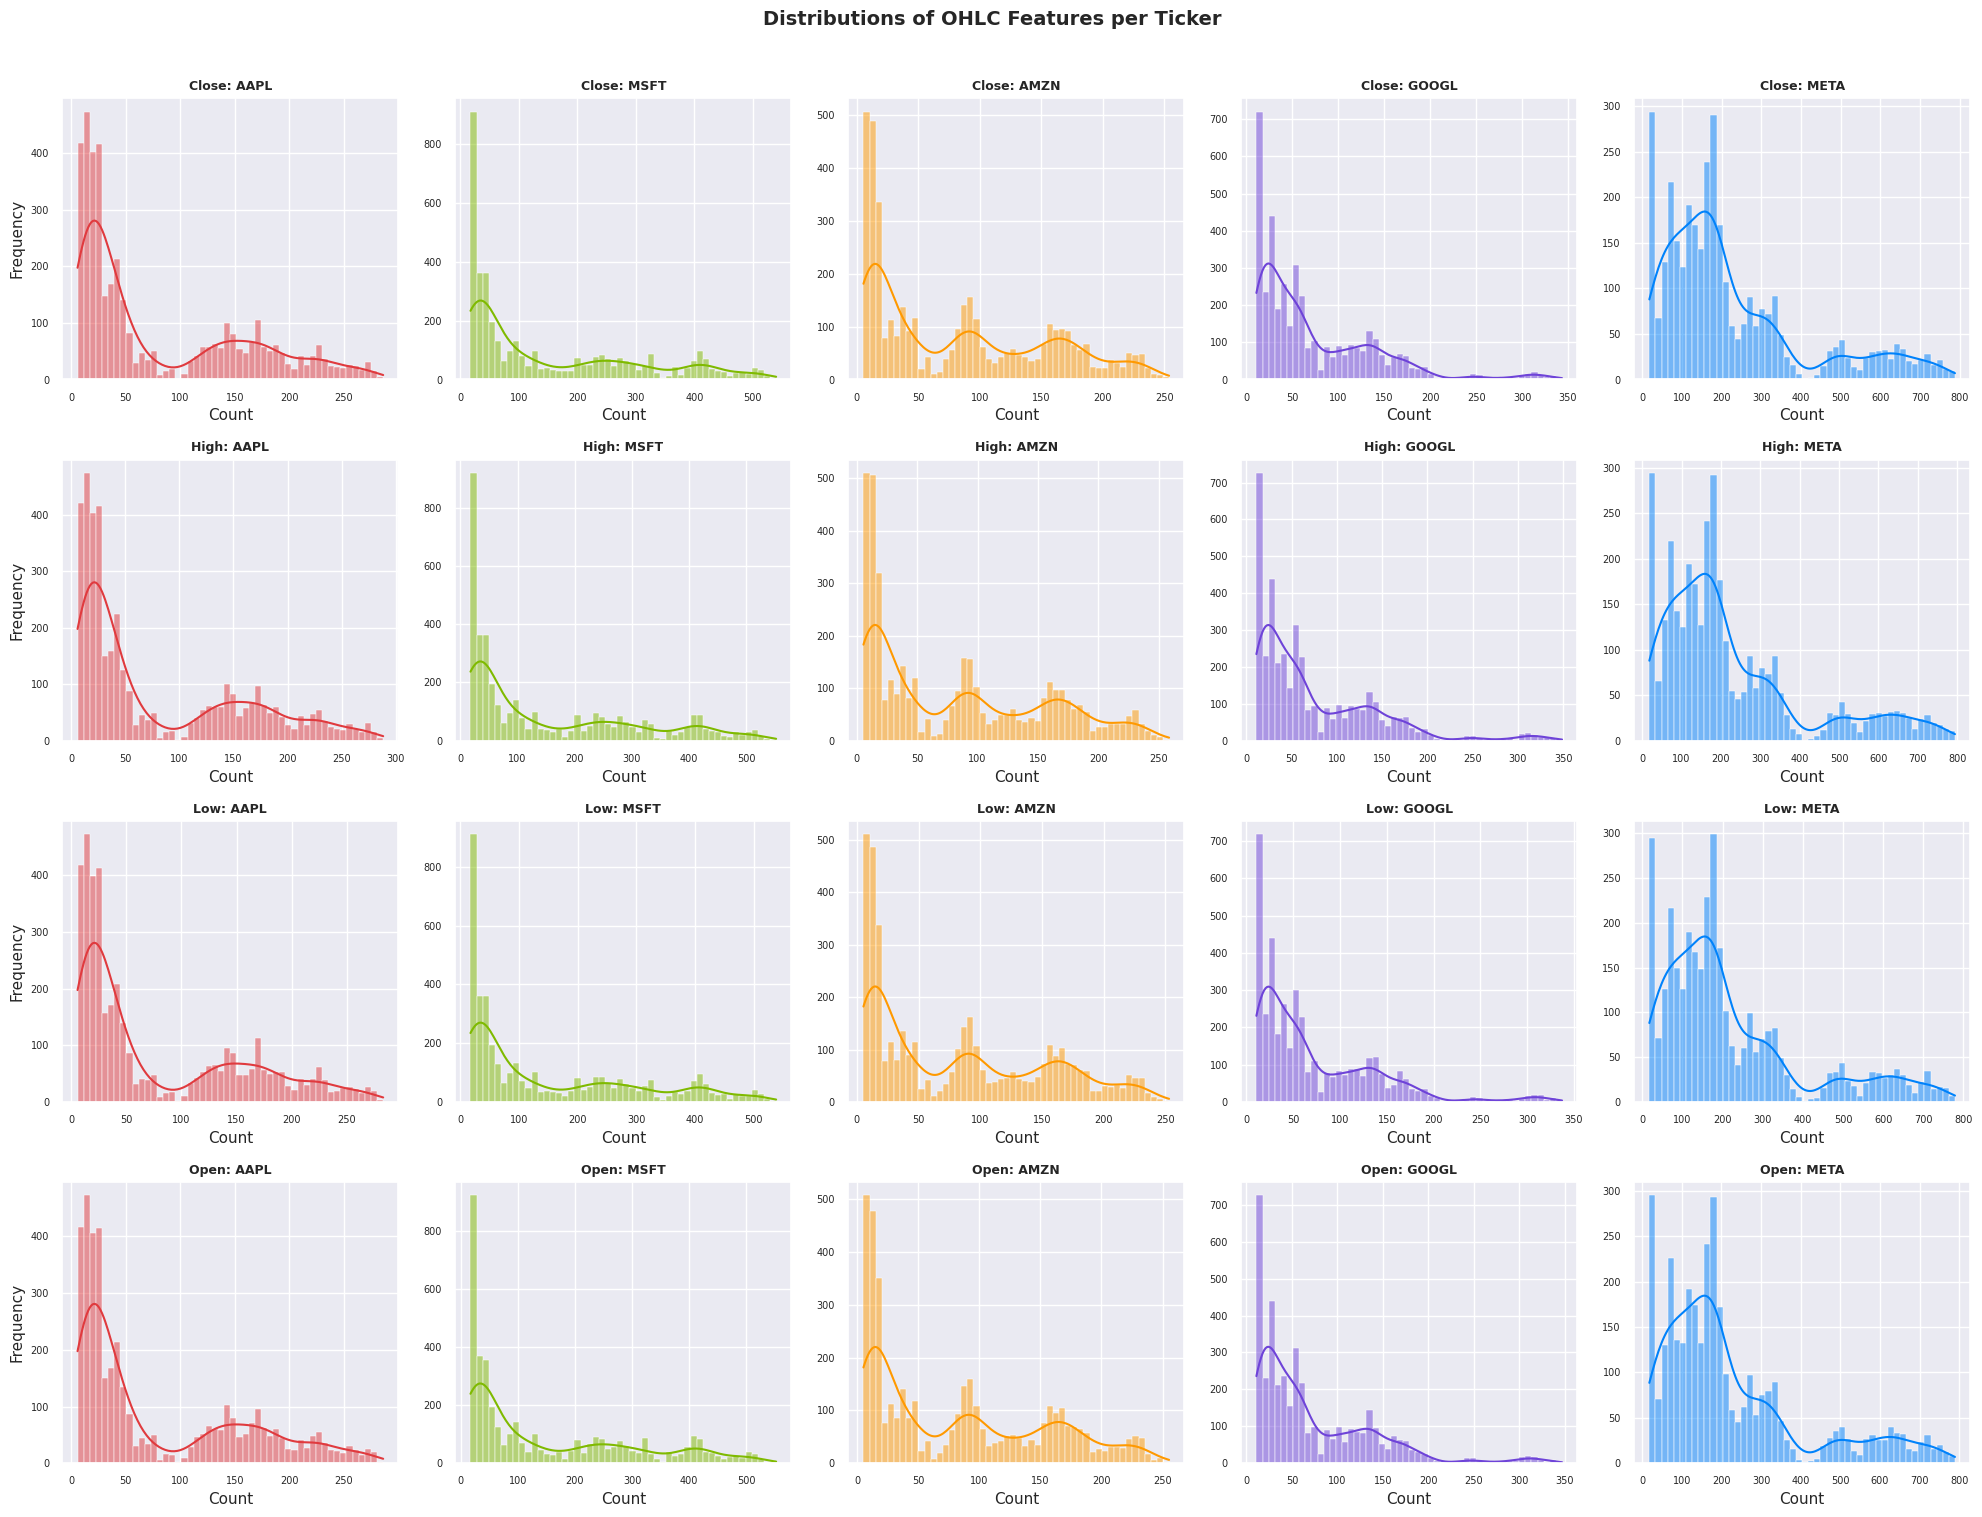

In [18]:
ohlc_cols = ["Close", "High", "Low", "Open"]

fig, axes = plt.subplots(len(ohlc_cols), len(tickers), figsize=(20, 15))

for i, feature in enumerate(ohlc_cols):
    for j, ticker in enumerate(tickers):
        ax = axes[i][j]
        sns.histplot(
            df[feature][ticker].dropna(),
            bins=50,
            ax=ax,
            kde=True,
            color=logo_palette[ticker],
        )
        ax.set_title(f"{feature}: {ticker}", fontsize=9)
        ax.set_xlabel("Count")
        ax.set_ylabel("Frequency" if j == 0 else "")
        ax.tick_params(labelsize=7)

plt.suptitle("Distributions of OHLC Features per Ticker", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

* Data is right tailed and positively skewed as expected for financial data, where most trading days cluster at lower price ranges and we can observe prices trending upward over time (early low prices and later high prices)
* AAPL, AMZN and META show secondary rises in their counts and KDE curves - suggests that these stocks went through different market regimes, growth phases, splits and more.

*We will take a second closer look at the Close Prices later on since it is the target variable to forecast.*

### Volume

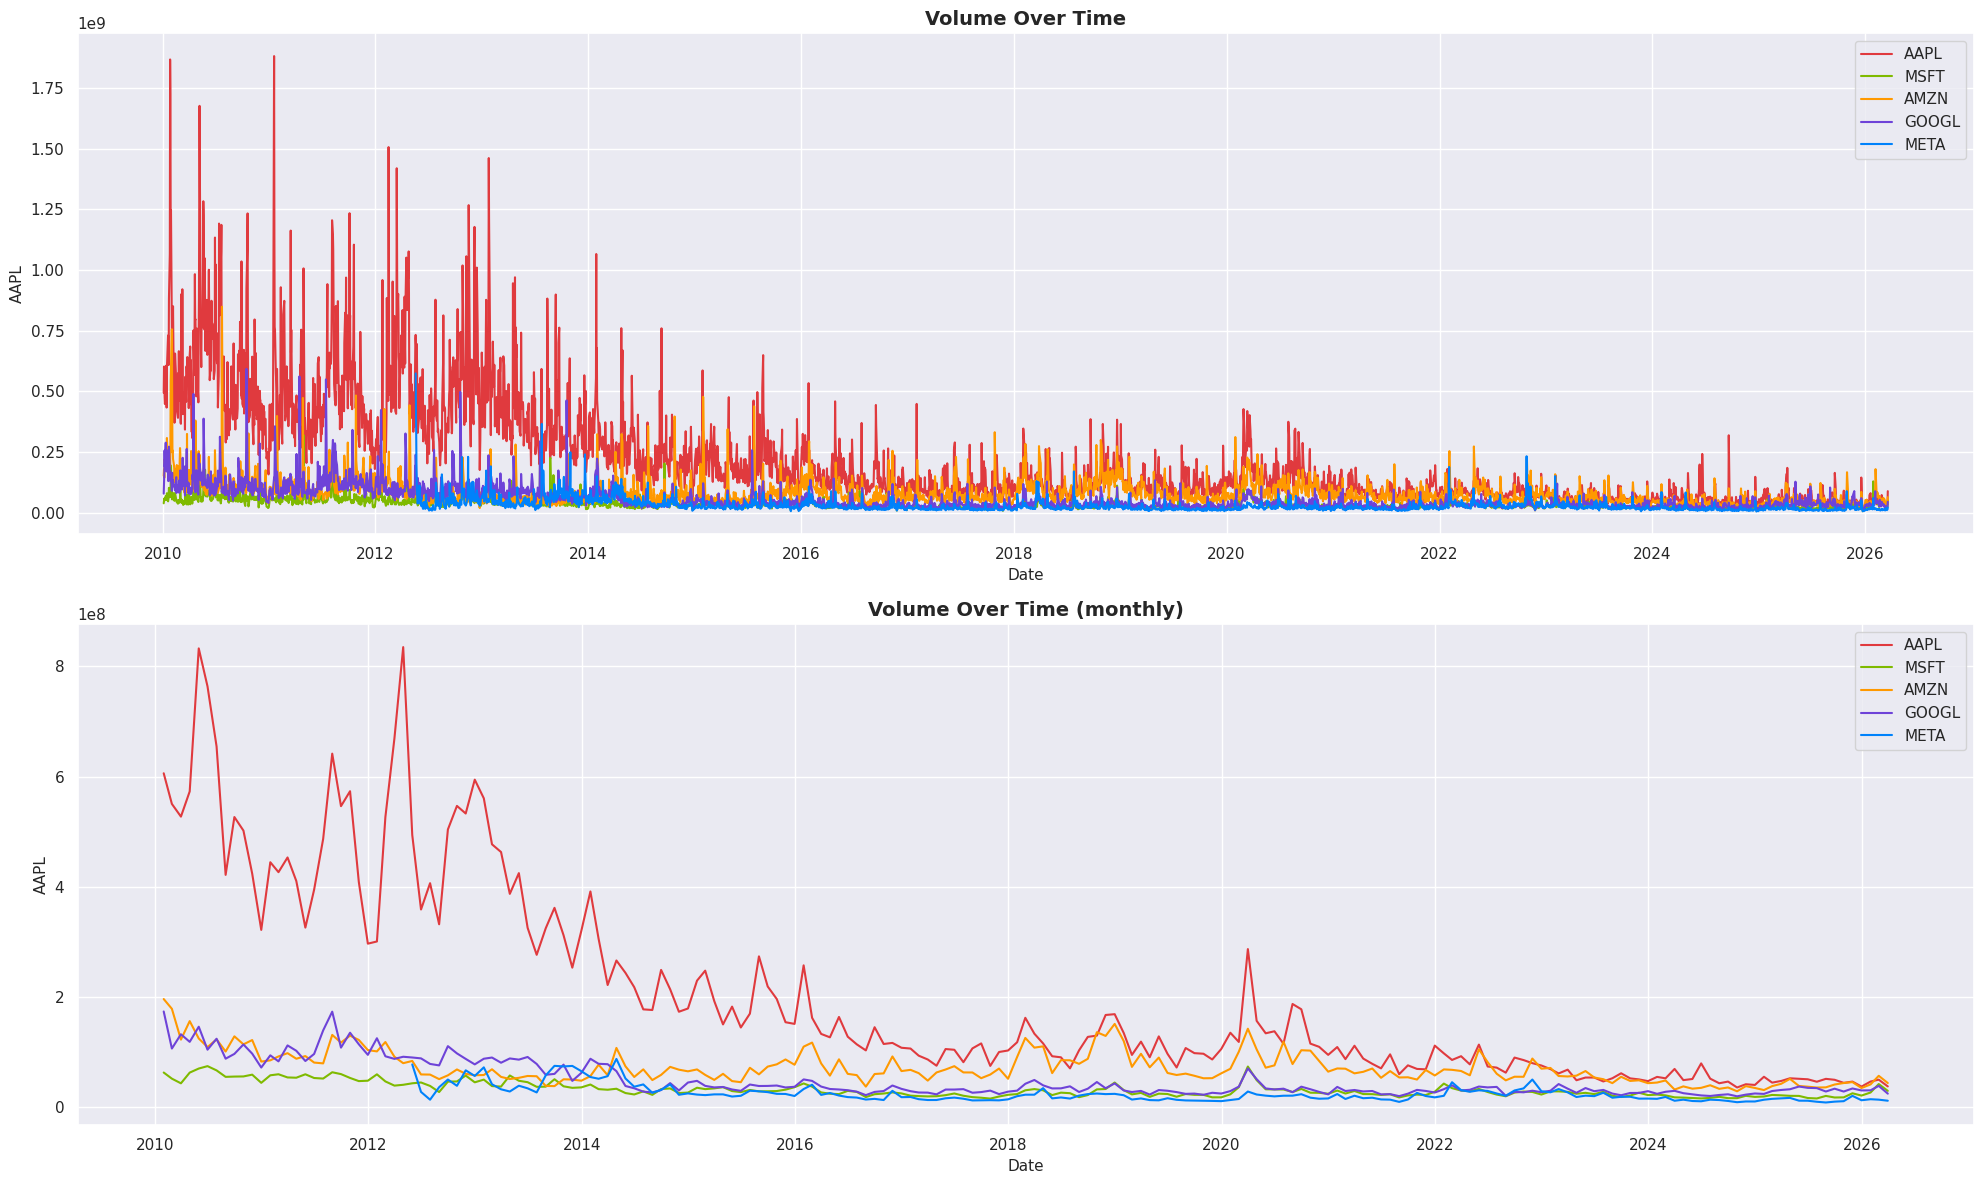

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

for ticker in tickers:
    sns.lineplot(
        data=df["Volume"],
        x=df.index,
        y=ticker,
        color=logo_palette[ticker],
        label=ticker,
        ax=axes[0],
    )
axes[0].set_title("Volume Over Time")
axes[0].tick_params(axis="x", rotation=0)

volume_monthly = df["Volume"].resample("ME").median()[tickers]
for ticker in tickers:
    sns.lineplot(
        data=volume_monthly,
        x=volume_monthly.index,
        y=ticker,
        color=logo_palette[ticker],
        label=ticker,
        ax=axes[1],
    )
axes[1].set_title("Volume Over Time (monthly)")

plt.tight_layout()
plt.show()

* Apple comparatively had an exponential amount of stock volume compared to the other 4 in the early 2010s. Reflectively if we look back on those years, Apple was the biggest tech innovator that brought about the concept of smartphones as a whole to the world, possibly explaining the large amount of shares in this period.
* In recent years Amazon follows closely with 2nd largest amount of shares.
* META has the lowest amount of shares.

### Returns & Volatility

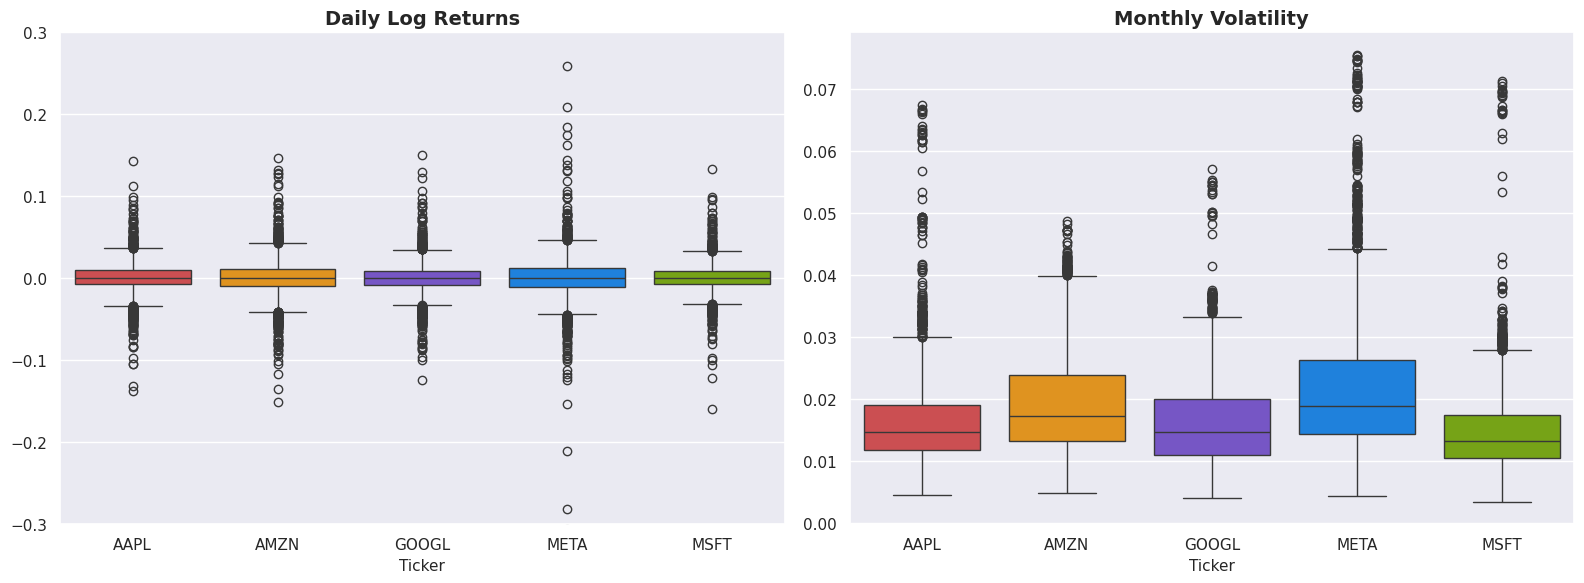

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df["Return"], palette=logo_palette, ax=axes[0])
axes[0].set_title("Daily Log Returns")
axes[0].set_ylim(-0.3, 0.3)

sns.boxplot(data=df["Volatility"], palette=logo_palette, ax=axes[1])
axes[1].set_title("Monthly Volatility")

plt.tight_layout()
plt.show()

* All assets except META stay within ±0.2 daily log returns.
* META has the largest expanse in returns and highest volatility.

#### Volatility Over The Years

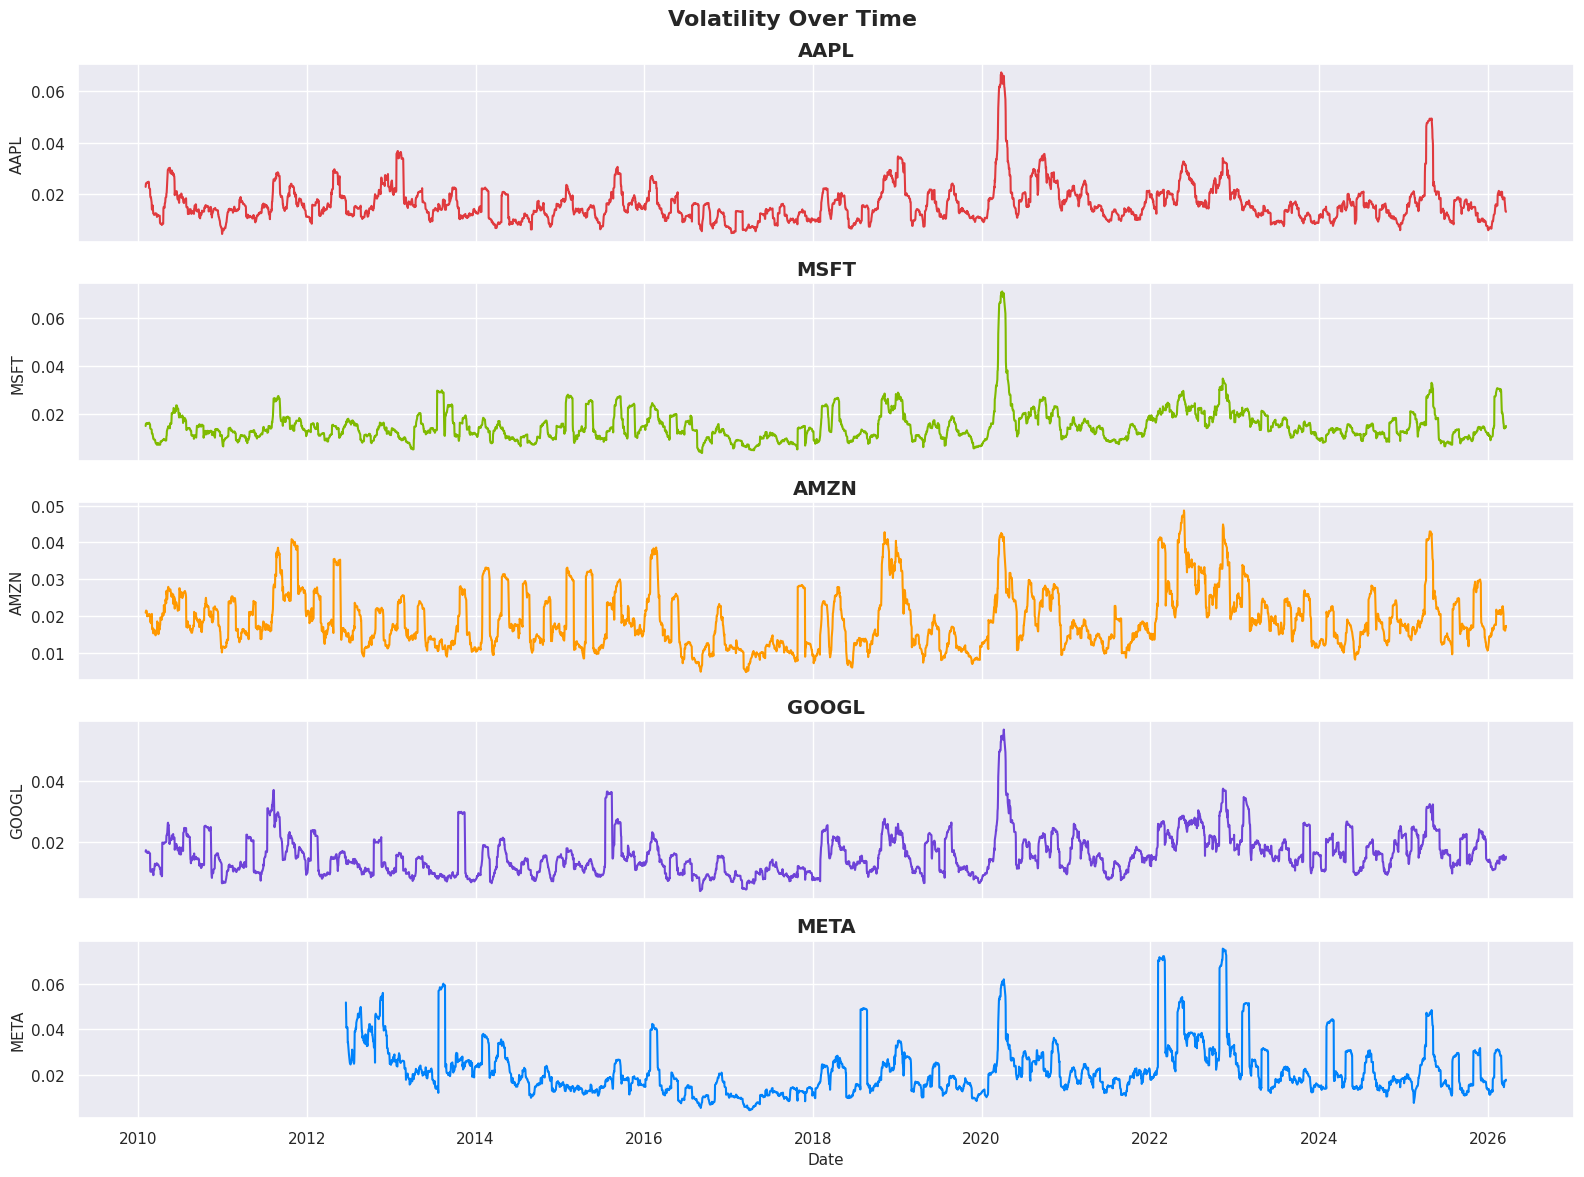

In [21]:
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)

for i, ticker in enumerate(tickers):
    sns.lineplot(data=df["Volatility"][ticker], ax=axes[i], color=logo_palette[ticker])
    axes[i].set_title(ticker)

plt.suptitle("Volatility Over Time")
plt.tight_layout()
plt.show()

* Clear volatility during the onset of the pandemic in 2020.
* META visibly has the most movement here as possibly the most volatile asset, next to AMZN. 

### Close Prices

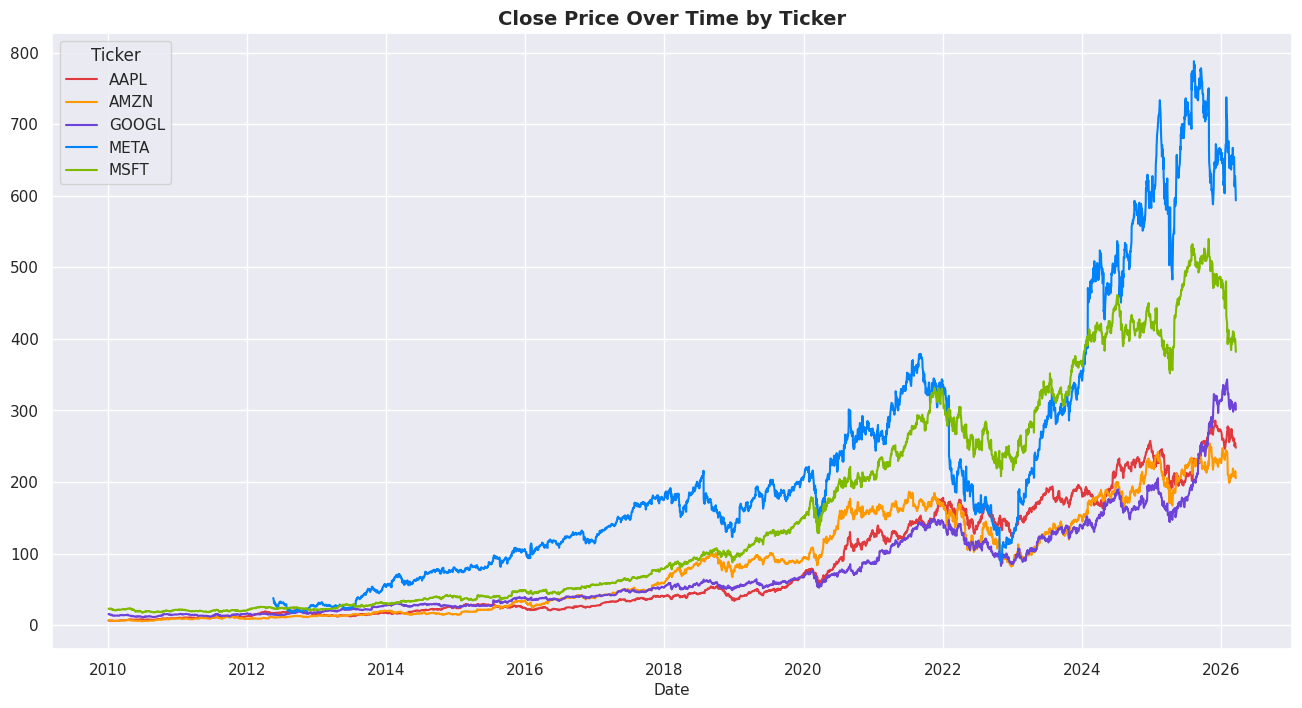

In [22]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=df["Close"], palette=logo_palette, dashes=False)
plt.title("Close Price Over Time by Ticker")
plt.show()

* Clear upward trend over the years reflecting the explosive growth of the tech industry. 
* META dominates Close prices with the highest values.
    * Sharp drop in 2022 but earns the most again in most recent years starting 2024.
* In this most recent year, prices are beginning to drop in 2026.

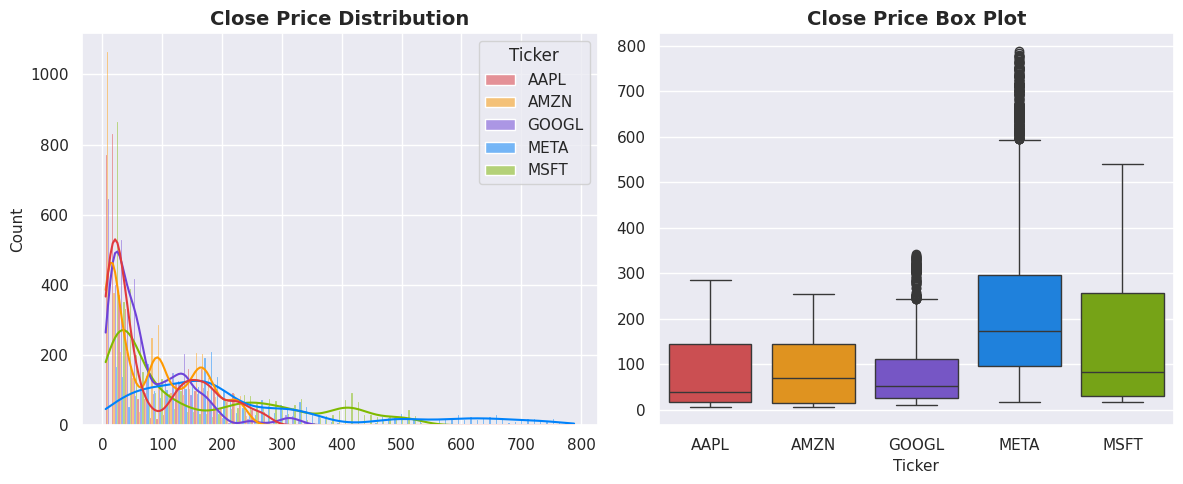

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    data=df["Close"], kde=True, palette=logo_palette, multiple="dodge", ax=axes[0]
)
axes[0].set_title("Close Price Distribution")

sns.boxplot(data=df["Close"], palette=logo_palette, ax=axes[1])
axes[1].set_title("Close Price Box Plot")

plt.tight_layout()
plt.show()

Again META has the highest close prices solely comprising the tail of the data, next to MSFT.

### Seasonal Decomposition

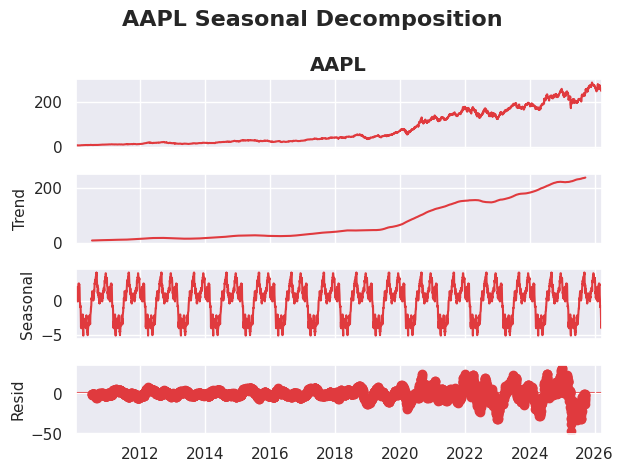

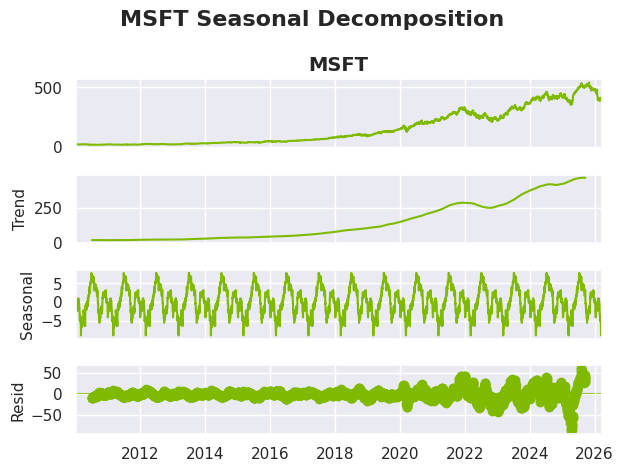

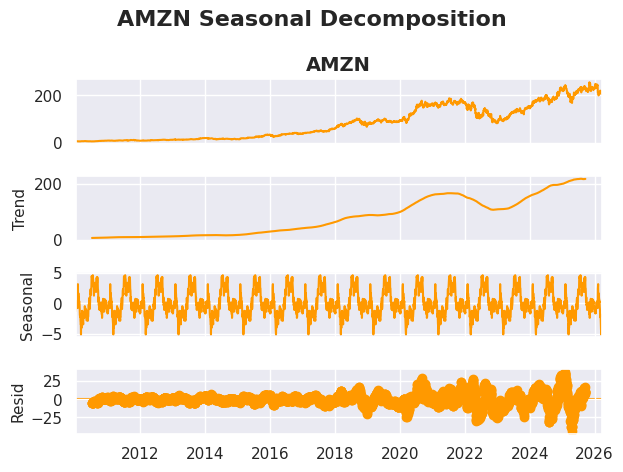

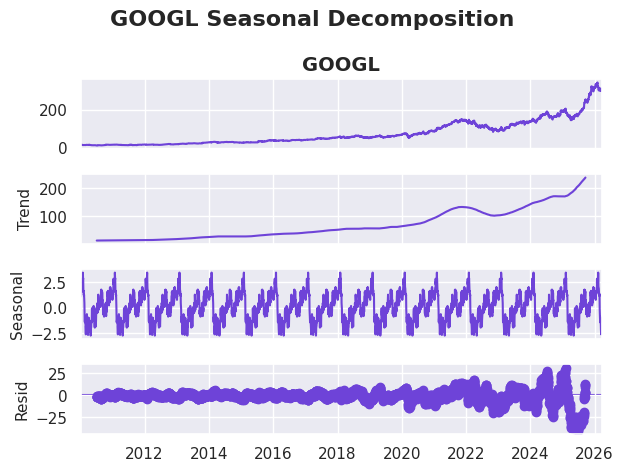

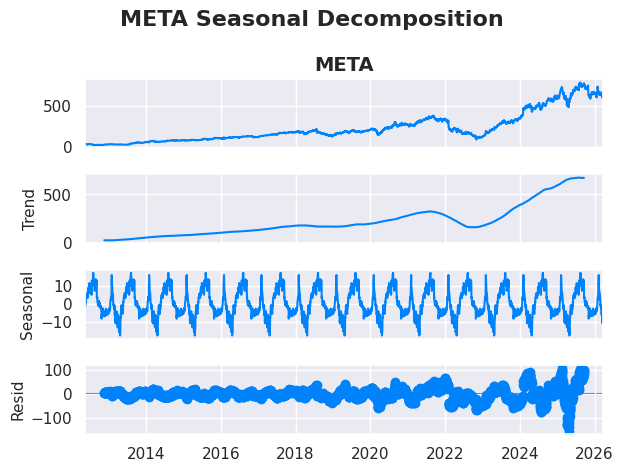

In [24]:
for ticker in tickers:
    series = df["Close"][ticker].dropna()
    decomposition = seasonal_decompose(series, model="additive", period=252)
    fig = decomposition.plot()
    for ax in fig.axes:
        for line in ax.get_lines():
            line.set_color(logo_palette[ticker])
    plt.suptitle(f"{ticker} Seasonal Decomposition")
    plt.tight_layout()
    plt.show()

Every asset displays the following:
* Trend: Clear long-term increasing trend in close prices as seen earlier
* Seasonal: Reveals recurring price patterns that repeat annually, possibly from quarterly earning, EOY or holiday cycles.
* Residuals: Dramatically increased residual fluctuations and volatility from 2020 onward.

⚠️ Trends need to be addressed for predictive modelling further on in this notebook.

### Correlations

#### Numerical Features Correlations

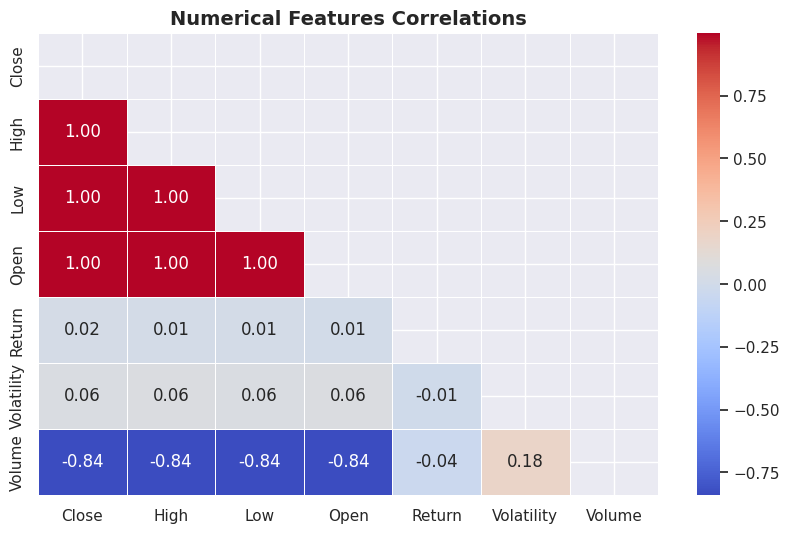

In [25]:
corr = df.T.groupby(level=0).mean().T.corr(method="spearman")
matrix = np.triu(corr)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, mask=matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Numerical Features Correlations")
plt.show()

* OHLC: These correlations are to be expected with OHLC essentially measuring the same underlying price of the trading day.
* Volume and Price (-0.84): With historical price data this is also to be expected, with more shares being traded at low prices. 

### Return Correlations

Do the 5 stocks move similarly when looking at daily returns?

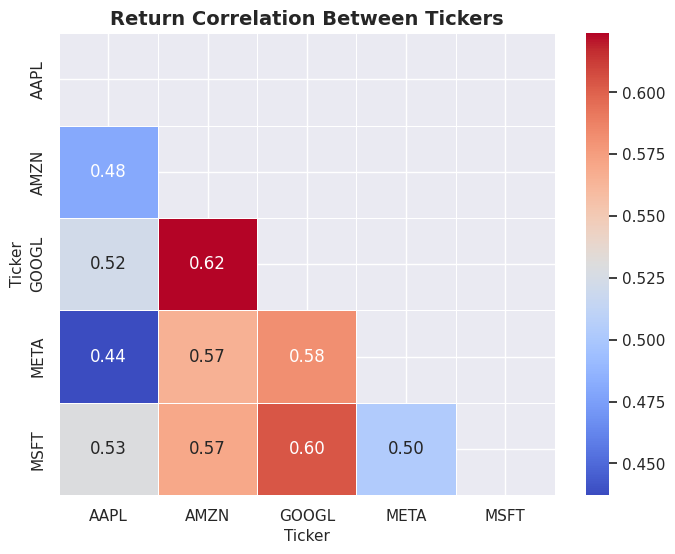

In [26]:
corr = df["Return"].corr(method="spearman")

matrix = np.triu(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Return Correlation Between Tickers")
plt.show()

Assets have moderate positive correlations ranging from *+0.44 to +0.62* suggesting that **returns between these 5 companies move in the same direction more often than not.**

### Key Findings in EDA:
- META has mostly shown the highest close prices and is the most volatile asset. 
- Second highest close prices comes from MSFT.
- **Upward increasing trends** across all equities.
- Stock returns between the 5 companies are moderately correlated which suggests similar movement.

## 3. Statistical Inference

### 3.1 Ranking Inference 

Ranking the 5 stocks by which is most likely to give best returns. *Ranking will also be modelled further on (see Chapter 6) and we may compare statistical results found here to modelling results in the later chapter.*

#### **Sharpe Ratio** 
The Sharpe Ratio will be used to rank which stocks are the most efficient according to return per unit of risk. 

This ratio is a measure of an investment's risk-adjusted performance, **defined by the difference between returns (mean returns) and the risk-free return (divided by the standard deviation of the returns)**

$$\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}$$

Where: 
- $R_p$ = mean returns
- $R_f$ = Risk-free rate of return 
- $\sigma_p$ = Standard deviation of returns (volatility) 

Interpretation: 

- **Higher Sharpe ratio implies better returns for risk** taken while lower indicates worse returns or volatility.

#### 3.1.1 Ranking Over All Historical Data:

In [27]:
sharpe_rank(df, time="overall")

,Ticker,Sharpe,CI_Low,CI_High,Rank
0,AAPL,0.7930,0.7567,0.8294,1
1,MSFT,0.7758,0.7396,0.8119,2
2,META,0.7392,0.7002,0.7781,3
3,AMZN,0.7256,0.6900,0.7612,4
4,GOOGL,0.6677,0.6326,0.7027,5


* Confidence Intervals: The confidence intervals never cross zero and are statistically significant to be within these 95% interval bounds.

* Ranking over time:
    * According to the Sharpe ratios where lower suggests better return-to-risk ratio, the stocks are ranked as follows over the past 16 years as follows:
        1. AAPL
        2. MSFT
        3. META
        4. AMZN
        5. GOOGL
    * All stocks have positive Sharpe ratios and returns.

#### 3.1.2 Ranking Over Last Trading Year

In [28]:
sharpe_rank(df, time="latest")

,Ticker,Sharpe,CI_Low,CI_High,Rank
0,GOOGL,1.8877,1.6808,2.0946,1
1,AAPL,0.3288,0.2015,0.4562,2
2,AMZN,0.0179,-0.1061,0.1420,3
3,META,-0.0609,-0.1851,0.0632,4
4,MSFT,-0.1933,-0.3185,-0.0681,5


Over the past year, ranking is different as follows:
1. GOOGL - largest gap in Sharpe ratio with over 1.8 score gap
2. AAPL
3. AMZN
4. META - negative performance
5. MSFT - negative performance

* The past year has bigger gaps between return-to-risk ratio, with GOOGL having a large gap from the others with a +1.8 Sharpe ratio
* Ratios over the last year are much smaller in measure (-0.02 to 0.46) in the recent market, compared to over-time historical ratios (0.76 to 0.89).

### Key Statistical Findings:
* The market ranking predictions vary differently for the past year than compared to historical data. 

| Stock | Ranking (All Time) | Ranking (Last Year) |
|-------|------------------|---------------------|
| AAPL  | 1                | 2                   |
| MSFT  | 2                | 5                   |
| META  | 3                | 4                   |
| AMZN  | 4                | 3                   |
| GOOGL | 5                | 1                   |

## 📈 4. Time-Series Forecasting

In this portion, time-series forecasting models will be built to predict closing prices over the next month. Different models will be trialed to see which ones perform best on the data. Note: performance of each model on each stock will be evaluated independently - stocks do not affect each other. 

### 4.0 Data Preparation

Before forecasting, our time series data needs to have date as its Index which was already achieved. Second, data needs to be stationary.

Nulls that META has in its 2 years will be dropped but all historical data in the 4 other equities will be kept.

#### Stationarity
##### Checking for Stationarity

Using the ADF test we can observe if the data is stationary; a requirement for many time-series models like ARIMA. A p-value less than 0.05 will state that it is stationary.

In [29]:
df_close = df["Close"].copy()
for ticker in tickers:
    result = adfuller(df_close[ticker].dropna())
    print(f"{ticker} p-value: {result[1]:.4f}")

AAPL p-value: 0.9891
MSFT p-value: 0.9483
AMZN p-value: 0.9370
GOOGL p-value: 0.9986
META p-value: 0.9372


Data is **not stationary**, as expected of stock pricing and as observed earlier in multiple EDA plots. Differencing will be applied:

##### Differencing for Stationarity

In [30]:
df_diff = {}

for ticker in tickers:
    diff = df_close[ticker].diff().dropna()

    df_diff[ticker] = diff

    result = adfuller(diff)
    print(f"{ticker} diff p-value: {result[1]:.4f}")

AAPL diff p-value: 0.0000
MSFT diff p-value: 0.0000
AMZN diff p-value: 0.0000
GOOGL diff p-value: 0.0000
META diff p-value: 0.0000


✅ Significant p-values = 0. Data is now stationary for ARIMA modelling.

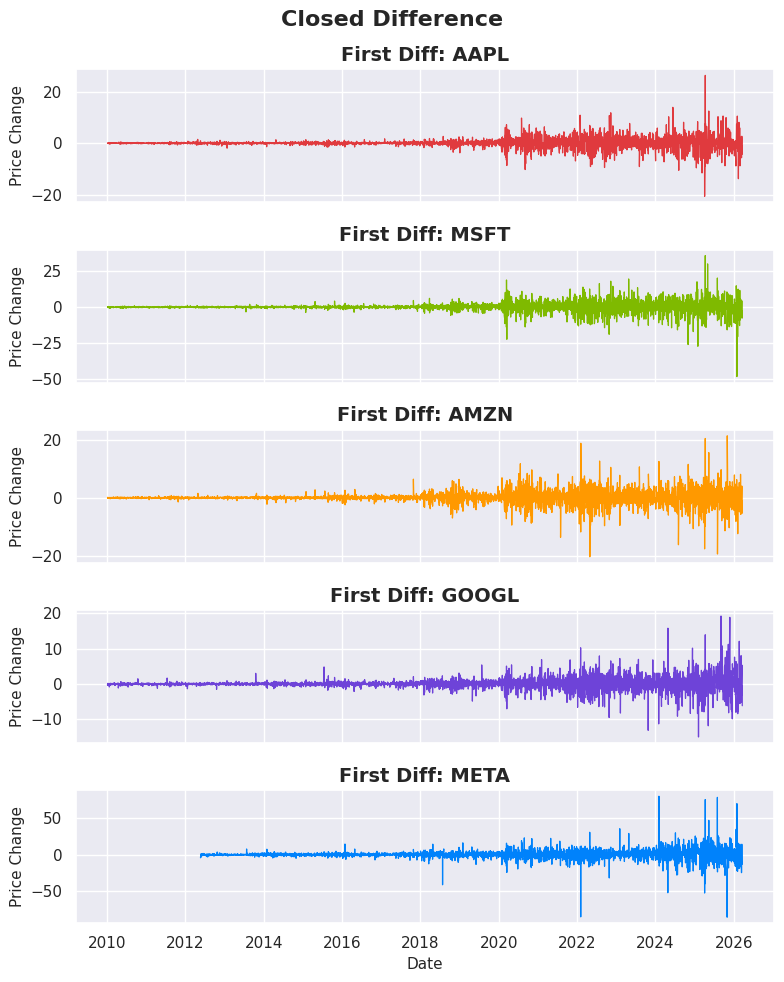

In [31]:
n = len(tickers)
fig, axes = plt.subplots(n, 1, figsize=(8, 2 * n), sharex=True)

for i, ticker in enumerate(tickers):
    sns.lineplot(
        x=df_diff[ticker].index,
        y=df_diff[ticker],
        ax=axes[i],
        linewidth=0.9,
        color=logo_palette[ticker],
    )
    axes[i].set_title(f"First Diff: {ticker}")
    axes[i].set_ylabel("Price Change")

plt.suptitle("Closed Difference")
plt.tight_layout()
plt.show()

* META and MSFT have the lowest dip in differenced close prices reaching -50

Dropping nulls and aligning data

In [32]:
forecast_df = {}

for ticker in tickers:
    level_series = df_close[ticker].dropna()
    diff_series = level_series.diff().dropna()

    level_series = level_series.iloc[1:]

    forecast_df[ticker] = {
        "diff": diff_series.values,
        "level": level_series.values,
    }

### 4.1 Modelling

**Validation: Walk-Forward Validation**
* Models will be built and trained over specific time windows. 
* **Training window is 1 trading year = 252** 
* **Test window is 1 trading month = 21**

Overall this validation format helps for more realistic monthly reforecasting

**Model Types:**

Different types of forecasting models will be explored here:
1. Simple Baseline Models - Moving Average
2. Exponential Smoothing Models - SES Model (Simple Exponential Smoothing)
3. ARIMA Models - ARIMA
4. Machine Learning Models - LightGBM

**Key Performance Metric: RMSE**
* RMSE will be our model performance metric of focus to view price prediction error while penalizing larger errors more heavily.
* MAE and MAPE will also be listed. Having MAPE (%) will allow for cross-asset comparability.

#### Baseline / Model 0: Moving Average (MA)
Given that our model is trained over windows, our baseline will follow the same pattern and average over a fixed window. Calculating the average of past observations over a fixed window size (month) and uses this average as the prediction for the next time step. 

In [33]:
results = None

for ticker in tickers:
    results, actuals, preds, folds, model = walk_forward_validation(
        series=forecast_df[ticker]["diff"],
        model_fn=ma_baseline_model,
        ticker=ticker,
        model_name="MA Baseline",
        results=results,
        series_level=forecast_df[ticker]["level"],
        invert_diff=True,
    )

results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,MA Baseline,4.7496,4.0239,4.8044,0.0147
1,MSFT,MA Baseline,8.3208,7.1498,4.3488,-0.1547
2,AMZN,MA Baseline,6.6465,5.6634,6.0444,-0.2114
3,GOOGL,MA Baseline,4.6252,3.9886,4.9915,-0.0833
4,META,MA Baseline,17.7054,15.5114,6.3551,0.0595


Baseline tends to underpredict and have lower value forecasts. RMSE ranges from 4 to 17 for the highest volatile stock.

#### Model 1: SES Model

SES Models give more weight to recent observations yet forecasting using all previous values. 

In [34]:
for ticker in tickers:
    results, actuals, preds, folds, model = walk_forward_validation(
        series=forecast_df[ticker]["diff"],
        model_fn=ses_model,
        ticker=ticker,
        model_name="SES",
        results=results,
        series_level=forecast_df[ticker]["level"],
        invert_diff=True,
    )

results = results.sort_values(["Ticker", "RMSE"]).reset_index(drop=True)
results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,SES,4.1759,3.5423,4.2712,-0.0213
1,AAPL,MA Baseline,4.7496,4.0239,4.8044,0.0147
2,AMZN,SES,5.3890,4.5719,5.0307,-0.4768
3,AMZN,MA Baseline,6.6465,5.6634,6.0444,-0.2114
4,GOOGL,SES,3.9465,3.3540,4.1031,-0.0495
5,GOOGL,MA Baseline,4.6252,3.9886,4.9915,-0.0833
6,META,SES,16.4087,14.4019,5.8396,0.8765
7,META,MA Baseline,17.7054,15.5114,6.3551,0.0595
8,MSFT,SES,6.7074,5.7089,3.6267,-0.3103
9,MSFT,MA Baseline,8.3208,7.1498,4.3488,-0.1547


The SES model shows better performance across every asset and every metric. However there is also a tendency for more bias.

#### Model 2: ARIMA Model

*Auto-ARIMA was checked off-notebook to determine the optimal p and q values for ARIMA order. (1,0,1) was returned and used.*

In [35]:
final_models = {ticker: {} for ticker in tickers}

for ticker in tickers:
    results, actuals, preds, folds, model = walk_forward_validation(
        series=forecast_df[ticker]["diff"],
        model_fn=arima_model,
        ticker=ticker,
        model_name="ARIMA",
        results=results,
        series_level=forecast_df[ticker]["level"],
        invert_diff=True,
    )
    final_models[ticker]["arima"] = model

results = results.sort_values(["Ticker", "RMSE"]).reset_index(drop=True)
results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,ARIMA,3.8919,3.2908,4.0390,0.0112
1,AAPL,SES,4.1759,3.5423,4.2712,-0.0213
2,AAPL,MA Baseline,4.7496,4.0239,4.8044,0.0147
3,AMZN,ARIMA,4.7085,3.9652,4.4572,-0.2210
4,AMZN,SES,5.3890,4.5719,5.0307,-0.4768
5,AMZN,MA Baseline,6.6465,5.6634,6.0444,-0.2114
6,GOOGL,ARIMA,3.7742,3.2137,3.9216,0.2148
7,GOOGL,SES,3.9465,3.3540,4.1031,-0.0495
8,GOOGL,MA Baseline,4.6252,3.9886,4.9915,-0.0833
9,META,ARIMA,14.3998,12.6254,5.3098,0.0631


**ARIMA always outperforms** the previous 2 models.

#### Model 3: LGB Model

The model was tuned beforehand and the best found parameters were saved. `find_best_params` function and the options used can be found in the helper file.

Lag features over the past window (month) were also built and handled internally to improve model learning by feeding it useful lag features.

In [37]:
for ticker in tickers:
    results, actuals, preds, folds, model = walk_forward_validation(
        series=forecast_df[ticker]["diff"],
        model_fn=lgbm_model,
        ticker=ticker,
        model_name="LGBM",
        results=results,
        series_level=forecast_df[ticker]["level"],
        invert_diff=True,
    )
    final_models[ticker]["lgbm"] = model

#### 🏆️ Model Results

In [38]:
results = results.sort_values(["Ticker", "RMSE"]).reset_index(drop=True)
results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,ARIMA,3.8919,3.2908,4.0390,0.0112
1,AAPL,LGBM,3.9762,3.3510,4.1176,0.0732
2,AAPL,SES,4.1759,3.5423,4.2712,-0.0213
3,AAPL,MA Baseline,4.7496,4.0239,4.8044,0.0147
4,AMZN,ARIMA,4.7085,3.9652,4.4572,-0.2210
5,AMZN,LGBM,4.7348,3.9748,4.4026,-0.2477
6,AMZN,SES,5.3890,4.5719,5.0307,-0.4768
7,AMZN,MA Baseline,6.6465,5.6634,6.0444,-0.2114
8,GOOGL,LGBM,3.7655,3.1986,3.9246,0.1907
9,GOOGL,ARIMA,3.7742,3.2137,3.9216,0.2148


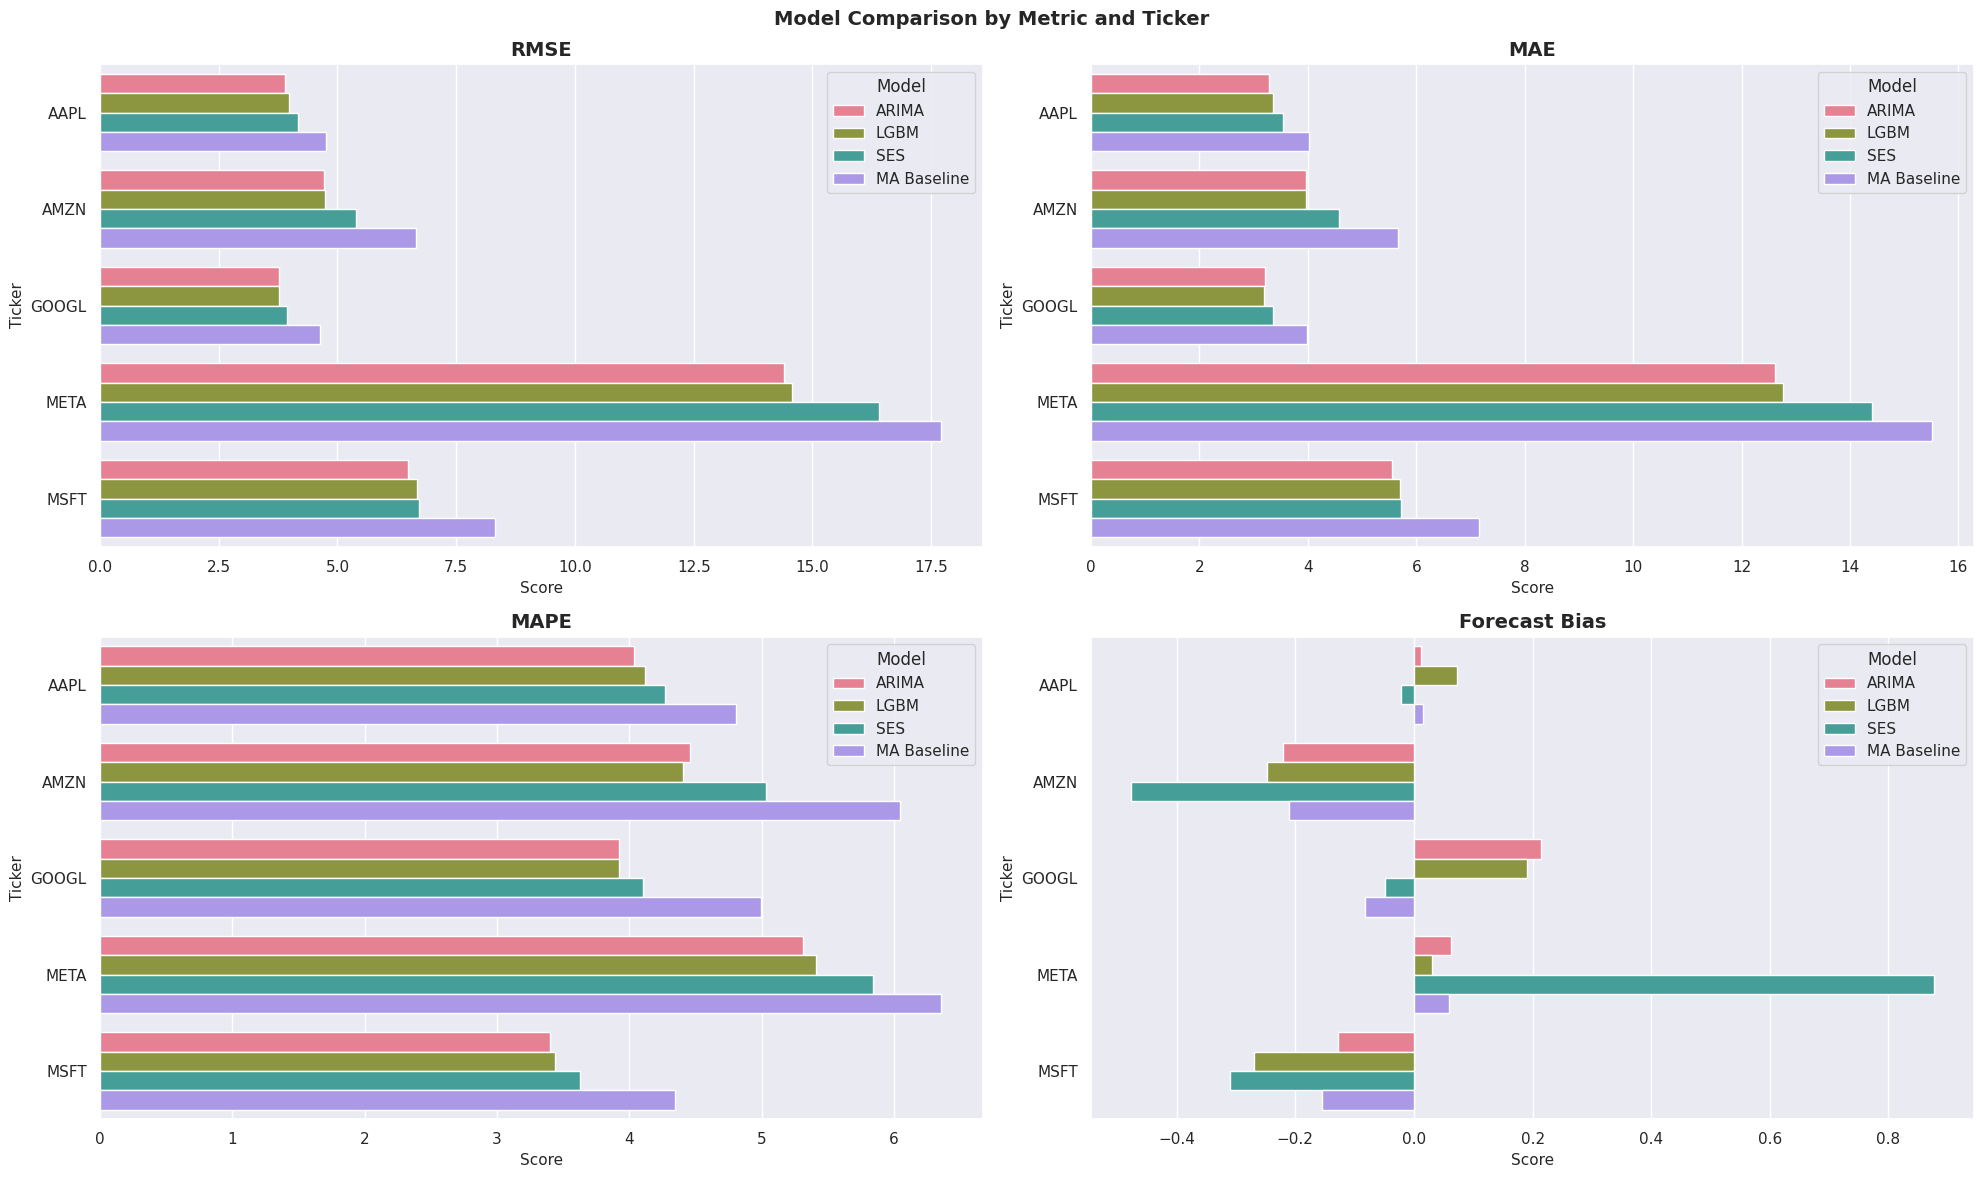

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

metrics = ["RMSE", "MAE", "MAPE", "Forecast Bias"]

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=results,
        x=metric,
        y="Ticker",
        hue="Model",
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel("Score")
    ax.legend(title="Model", bbox_to_anchor=(1, 1))

plt.suptitle("Model Comparison by Metric and Ticker", fontsize=14)
plt.tight_layout()
plt.show()

* ARIMA (seen in pink) & LGBM (green) compete very closely as the top 2 performing models across the board of metrics. 
* Their RMSEs may be negligibly 0.001 apart or up to 0.3 difference.
* Forecast Bias: 3/5 times ARIMA is less biased than LGBM. 
    * Interestingly LGBM really captures the most volatile asset with barely any forecast bias on META.

4/5 times ARIMA performs better and the performance follows this pattern: 
1. ARIMA
2. LGBM
3. SES
4. MA Baseline

(Except for GOOGL where LGBM performs better by 0.01 RMSE)

📌 In conclusion, **ARIMA performs the best with all this daily granular data**. ARIMA has slight edges over LGBM and is objectively less biased across the assets. 

### 4.2 Forecasting

With our strong performing ARIMA model, we can take a look at how the stock prices will be over the next month.

#### 4.2.1 Next Month's Forecast Plot

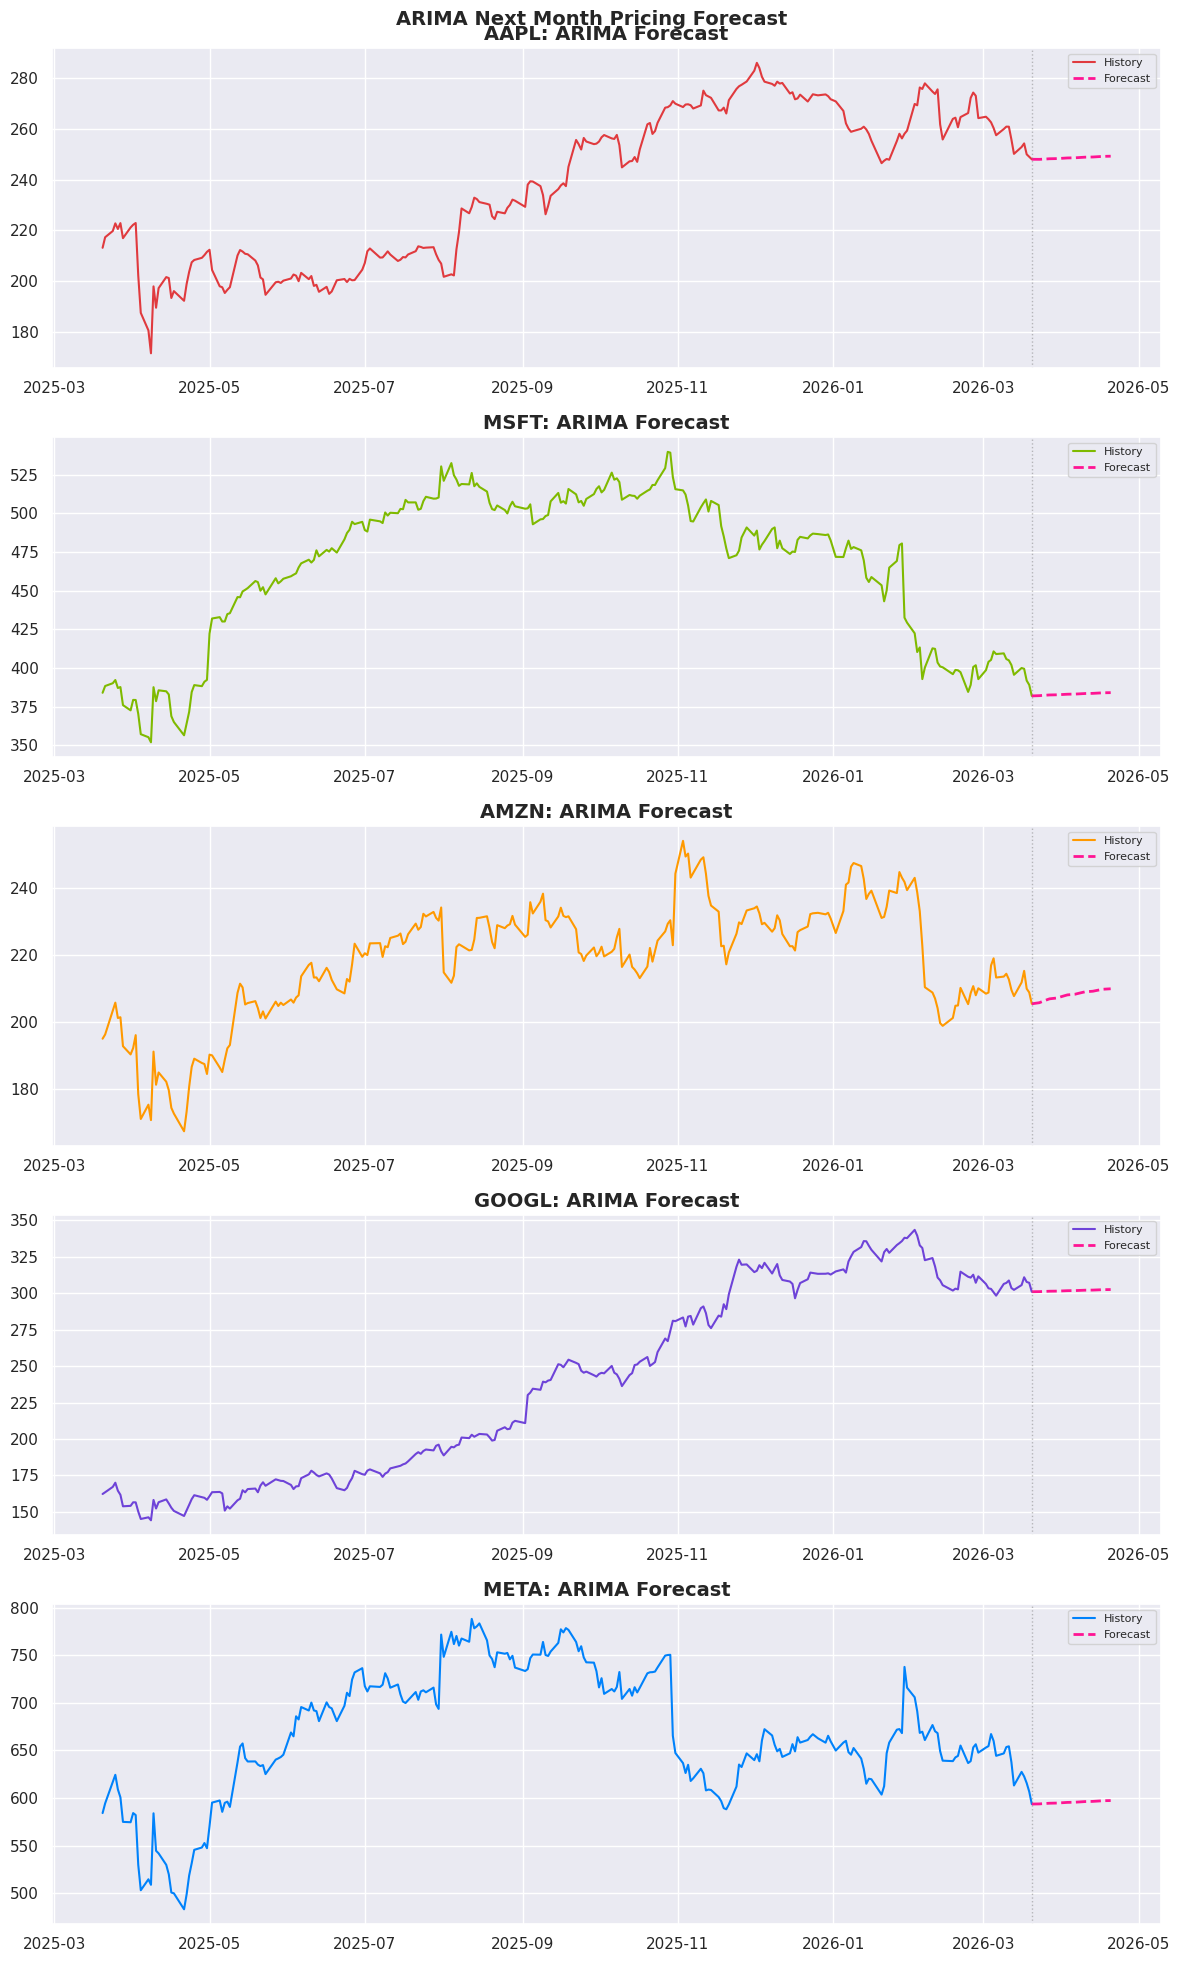

In [40]:
fig, axes = plt.subplots(len(tickers), figsize=(12, 4 * len(tickers)))
if len(tickers) == 1:
    axes = [axes]

for i, ticker in enumerate(tickers):
    plot_model_forecast(
        ticker,
        axes[i],
        df_close,
        final_models,
        palette=logo_palette,
        invert_diff=True,
    )

plt.suptitle("ARIMA Next Month Pricing Forecast", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Over the next month, movement of stock prices are relatively stable with no steep downward or upward momentum: most slight upward slopes.

According to the ARIMA forecast, the forecast that will **see the most growth in close prices over the next month will visually be AMZN.**

#### 4.2.2 Next Day Closing Prices

Using the yfinance data we can check the actual close prices on the next day, March 23, and compare how our predictions did.

In [41]:
next_day_preds = {}

for ticker in tickers:
    anchor = df_close[ticker].iloc[-1]

    arima_model_fit = final_models[ticker]["arima"]
    next_day_diff = arima_model_fit.forecast(steps=1)[0]
    next_day_preds[ticker] = anchor + next_day_diff

next_day_date = pd.bdate_range(start=df_close.index[-1], periods=2)[-1]

pred = pd.Series(next_day_preds, name="Predicted Close").round(2)
actual = get_actual_close(tickers).rename("Actual Close (2026-03-23)")
difference = (pred - actual).rename("Difference").round(2)
pct_diff = ((pred - actual) / actual * 100).round(2).rename("% Diff")

df_compare = pd.concat([pred, actual, difference, pct_diff], axis=1)

df_compare

,Predicted Close,Actual Close (2026-03-23),Difference,% Diff
AAPL,247.97,251.490005,-3.52,-1.40
MSFT,382.04,383.000000,-0.96,-0.25
AMZN,205.70,210.139999,-4.44,-2.11
GOOGL,301.07,302.059998,-0.99,-0.33
META,593.82,604.059998,-10.24,-1.70


Predicted close prices on March 23 are -0.25% and no more than -2.11% off.

## ⏱️ 5. Survival Analysis

> Using survival analysis methods, train models that are capable of predicting time to event (in this case event is ≥5% daily increase in stock price). <br> *Note: the model will be the same for all stocks. Model performance on each stock was evaluated independently.*

**📌 Event: ≥5% daily increase in stock price**


### 5.0 Preparing Data for Survival Analysis

For survival analysis we can engineer features for this purpose. 

Particularly we need:
1. `durations` - 🎯 target variable: number of days until event occurred 
2. `event_observed` (1 or 0): 1 if daily return is greater than or equal to 5%, else 0.

And make use of **covariate features**:
1. `avg_volatility`: volatility series pulled from the df, avg_vol computed over each window of event. Does volatility affect how quickly a 5% return happens?
2. `avg_volume`: volume and market interest on each window of event. Does market interest affect 5% event?

Note that META is left-censored / truncated with a later starting date compared to the other stocks. However since each ticker gets its own independent duration and is observed separately this is not an issue.

In [42]:
rows = []
df_copy = df.copy()

for ticker in tickers:
    survival_data = df_copy[
        [("Return", ticker), ("Volatility", ticker), ("Volume", ticker)]
    ].dropna()
    returns = survival_data[("Return", ticker)].values
    volatility = survival_data[("Volatility", ticker)].values
    volume = survival_data[("Volume", ticker)].values

    event = (returns >= np.log(1.05)).astype(int)

    last_event_idx = 0

    for i in range(len(returns)):
        if event[i] == 1:
            duration = i - last_event_idx

            vol_window = volatility[last_event_idx:i]
            avg_vol = vol_window.mean() if len(vol_window) > 0 else volatility[i]

            volume_window = volume[last_event_idx:i]
            avg_volume = np.log(
                volume_window.mean() if len(volume_window) > 0 else volume[i]
            )

            rows.append(
                {
                    "ticker": ticker,
                    "duration": duration,
                    "event_observed": 1,
                    "avg_volatility": avg_vol,
                    "avg_volume": avg_volume,
                }
            )

            last_event_idx = i + 1

    # final survival period - time from last event to end of data
    if last_event_idx < len(returns):
        duration = len(returns) - last_event_idx
        avg_vol = volatility[last_event_idx:].mean()
        avg_volume = np.log(volume[last_event_idx:].mean())

        rows.append(
            {
                "ticker": ticker,
                "duration": duration,
                "event_observed": 0,
                "avg_volatility": avg_vol,
                "avg_volume": avg_volume,
            }
        )

survival_df = pd.DataFrame(rows)
survival_df.head()

,ticker,duration,event_observed,avg_volatility,avg_volume
0,AAPL,53,1,0.015013,20.093298
1,AAPL,12,1,0.018376,20.506523
2,AAPL,315,1,0.014754,20.090383
3,AAPL,42,1,0.021262,20.238682
4,AAPL,72,1,0.016918,19.794350


In [43]:
print(
    survival_df.groupby("ticker").agg(
        {
            "duration": ["mean", "median", "max"],
            "event_observed": ["sum", "mean"],
        }
    )
)

print(f"\nTotal observations: {len(survival_df)}")
print(f"Events: {survival_df['event_observed'].sum()}")

          duration             event_observed          
              mean median  max            sum      mean
ticker                                                 
AAPL    100.450000   57.0  376             39  0.975000
AMZN     63.412698   30.0  377             62  0.984127
GOOGL   108.675676   74.0  797             36  0.972973
META     45.120000   15.0  501             74  0.986667
MSFT    134.266667   83.0  489             29  0.966667

Total observations: 245
Events: 240


### 5.1 Kaplan-Meier Curves

Kaplan Meier to visualize time-to-event

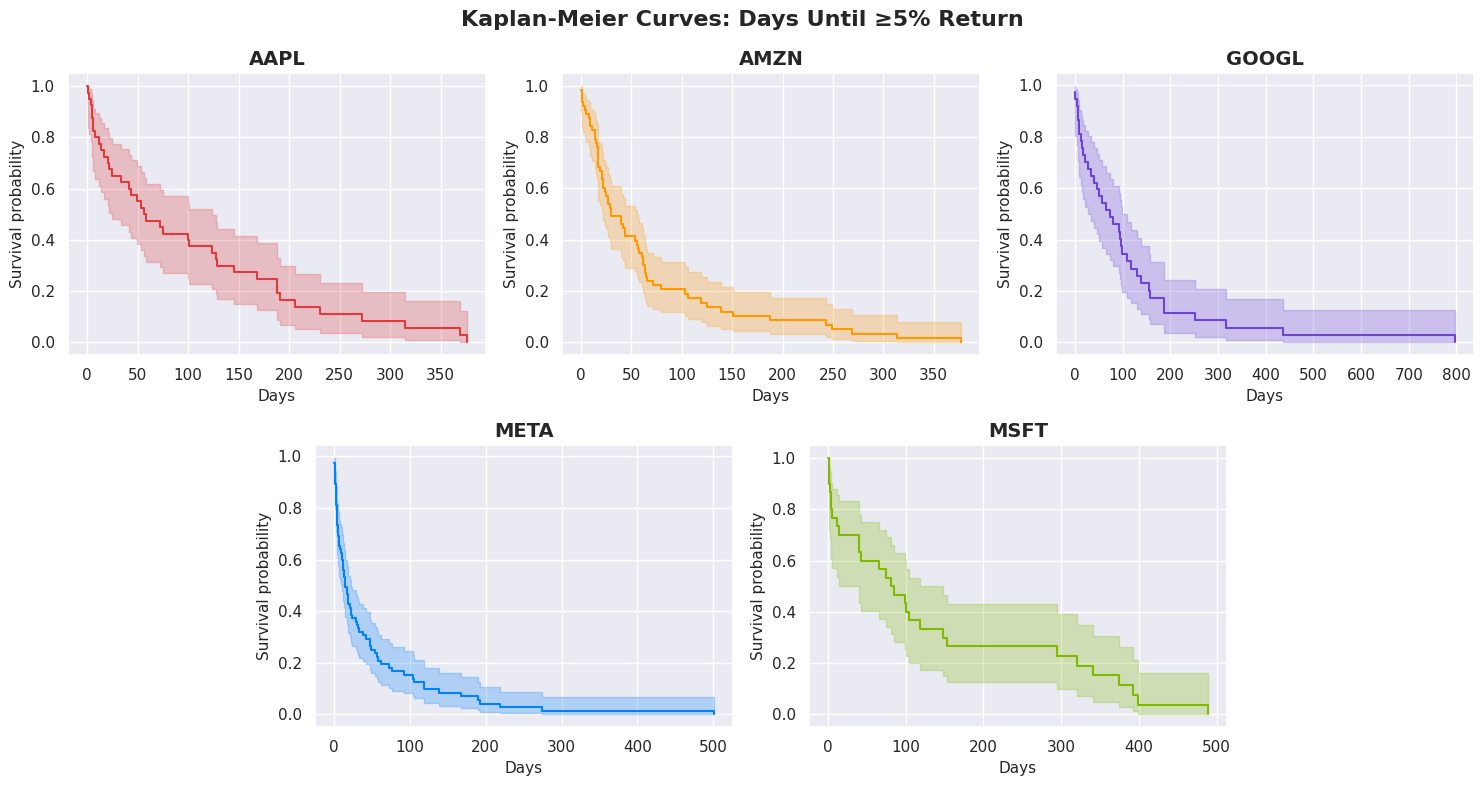

In [44]:
mosaic = """AABBCC
            .DDEE."""

fig, ax_dict = plt.subplot_mosaic(mosaic, figsize=(15, 8))


for ax_key, ticker in zip(
    sorted(ax_dict.keys()), sorted(survival_df["ticker"].unique())
):
    subset = survival_df[survival_df["ticker"] == ticker]

    kmf = KaplanMeierFitter()
    kmf.fit(subset["duration"], subset["event_observed"], label=ticker)
    kmf.plot_survival_function(
        ax=ax_dict[ax_key], ci_show=True, color=logo_palette[ticker]
    )

    ax_dict[ax_key].set_title(ticker)
    ax_dict[ax_key].set_xlabel("Days")
    ax_dict[ax_key].set_ylabel("Survival probability")
    ax_dict[ax_key].legend().remove()

fig.suptitle("Kaplan-Meier Curves: Days Until ≥5% Return")
plt.tight_layout()
plt.show()

* We recall the EDA showing META is a very volatile stock, and we can see that here again as its survival curve drops almost vertically - 5% increase happens almost constantly. This matches its high volatility seen throughout the notebook. Its confidence bands are narrow and remain low suggesting that 5% moves are in fact frequent.
* Wider confidence bands for other assets indicate more variability. 
* Survival curves drop most slowly for MSFT with almost lateral movement and no event time observed over a long period of days.

### Log-Rank Test

Determining if the survival curves seen above **differ significantly** between two or more groups

In [45]:
logrank_rows = []
results = None

for ticker_a, ticker_b in combinations(tickers, 2):
    a = survival_df[survival_df["ticker"] == ticker_a]
    b = survival_df[survival_df["ticker"] == ticker_b]

    results = logrank_test(
        a["duration"],
        b["duration"],
        event_observed_A=a["event_observed"],
        event_observed_B=b["event_observed"],
    )

    logrank_rows.append(
        {
            "ticker_a": ticker_a,
            "ticker_b": ticker_b,
            "p_value": round(results.p_value, 4),
        }
    )

logrank_df = pd.DataFrame(logrank_rows)

logrank_df_sorted = logrank_df.sort_values("p_value").reset_index(drop=True)

logrank_df_sorted.style.map(
    lambda val: f"color: {logo_palette.get(val, '')}", subset=["ticker_a", "ticker_b"]
).map(
    lambda val: "color: green; font-weight: 500" if val < 0.05 else "",
    subset=["p_value"],
).format(
    {"p_value": "{:.4f}"}
)

,ticker_a,ticker_b,p_value
0,MSFT,META,0.0012
1,AAPL,META,0.0020
2,GOOGL,META,0.0023
3,MSFT,AMZN,0.0050
4,AMZN,GOOGL,0.0505
5,AMZN,META,0.0580
6,AAPL,AMZN,0.0909
7,AAPL,MSFT,0.2159
8,MSFT,GOOGL,0.5367
9,AAPL,GOOGL,0.9722


* META is most different compared to the other assets - always having statistically different survival curves with p-values < 0.05
* AAPL and GOOGL have more similarities to other assets.

### 5.2 Cox Proportional Hazards Model

Estimate effects of covariates (Volatility) without making strong assumptions using a semi-parametric model, perfect for our complex and right-tailed financial data

In [46]:
covariate_cols = ["avg_volatility", "avg_volume"]

survival_results = []

for ticker in tickers:
    ticker_df = (
        survival_df[survival_df["ticker"] == ticker].dropna().reset_index(drop=True)
    )

    if len(ticker_df) < 2:
        continue

    ticker_df = ticker_df.copy()
    ticker_df[covariate_cols] = StandardScaler().fit_transform(
        ticker_df[covariate_cols]
    )

    cph = CoxPHFitter()
    cph.fit(
        ticker_df[["duration", "event_observed"] + covariate_cols],
        duration_col="duration",
        event_col="event_observed",
    )

    ci = cph.concordance_index_

    times = np.percentile(ticker_df["duration"], np.linspace(5, 95, 50))
    brier_scores = [
        np.mean(
            (
                cph.predict_survival_function(ticker_df[covariate_cols], times=[t])
                .loc[t]
                .values
                - (
                    ~((ticker_df["duration"] <= t) & (ticker_df["event_observed"] == 1))
                ).astype(float)
            )
            ** 2
        )
        for t in times
    ]
    ibs = np.nanmean(brier_scores)

    # Calculating median survival time when S(t) = 0.5 or when event has 50% median chance to happen
    avg_obs = ticker_df[covariate_cols].mean().to_frame().T
    surv_func = cph.predict_survival_function(avg_obs)
    past_median = surv_func.values.flatten() < 0.5
    time_to_event = (
        round(surv_func.index[past_median.argmax()], 1) if past_median.any() else np.inf
    )

    survival_results.append(
        {
            "ticker": ticker,
            "time_to_event": time_to_event,
            "concordance_index": round(ci, 4),
            "brier_score": round(ibs, 4),
        }
    )

results = None
results = (
    pd.DataFrame(survival_results)
    .sort_values("concordance_index", ascending=False)
    .reset_index(drop=True)
)
results

,ticker,time_to_event,concordance_index,brier_score
0,MSFT,40.0,0.8913,0.0788
1,AAPL,49.0,0.8331,0.1024
2,GOOGL,57.0,0.8320,0.1096
3,AMZN,40.0,0.7888,0.1161
4,META,19.0,0.7676,0.1361


Interpretation:
* Time to Event: Amount of days until the next ≥5% simple return, given current volatility regime
* Concordance Index: how well volatility ranks the risk ordering / can the model rank outcomes correctly?
* Brier Score: calibration of predicted survival probabilities / are predicted probabilities accurate?

### 5.3 Key Survival Findings:

* Concordance Indices are 0.76 above up to the ~0.89 range which are closer to 1.0 indicating strong ranking performance. The Cox model can effectively distinguish between shorter and longer time for return increase events. 
* Stocks with higher volatilty tend to experience 5% increase in returns sooner as seen with META (only 19 days until event)
* Volatility being the covariate is a good high index predictor of event timing for stable stocks like MSFT, GOOGL, and AAPL having the strongest signals and C-indices. 

## 🥇 6. Ranking

> Build ranking model that is capable of ranking given stocks in descending order in terms of possible daily gains from each stock.

> Ranking Models <br> We construct a relative ranking of stocks at each time step based on predicted returns or risk-adjusted metrics. This supports portfolio allocation and decision-making strategies that prioritize the most promising assets at any given moment.


* **🎯 Objective: Rank the 5 stocks based on possible daily gains from each stock**
* Model: LGB with lambdarank 
* Method: Pairwise
    * Ranking assets through pair combinations and directly comparing them to one another in order for a full implicit list. Given that we only have 5 assets this is a moderate number that we can create pairs with.   
* Evaluation: NDCG
    * NDCG is a metric that can emphasize ranking higher items closer to the top. Errors at the higher rank are penalized more. 

### 6.0 Data Preparation for Ranking

For Ranking, data needs to be organized as Query-Item pairs and have a Relevance Label:
* Query ID: Date
* Item ID: Ticker
* Relevance label: Indicate based on returns how relevant it is for the query

Features that describe the query-item pairs can assist the model: 
* Lag Returns
* Lag Volatility
* Lag Volume

🗒️ Truncating to **common start date**: The objective is to rank all 5 stocks so a common start date, where all 5 stocks exist will be used to train the data. We will not train on data where only 4 stocks existed.

In [47]:
rank_df = df.copy()
rank_df = rank_df.stack(level="Ticker", future_stack=True).reset_index()
rank_df = rank_df.dropna(subset=["Return", "Volatility", "Volume"])
rank_df = rank_df.sort_values(["Date", "Ticker"])

# Shift forward to tomorrow's return: value to predict
rank_df["ret_tomo"] = rank_df.groupby("Ticker")["Return"].shift(-1)
rank_df = rank_df.dropna(subset=["ret_tomo"])

# Truncate to common start from where all 5 stocks have data
common_start = rank_df.groupby("Ticker")["Date"].min().max()
rank_df = rank_df[rank_df["Date"] >= common_start]
rank_df = rank_df.sort_values(["Date", "Ticker"]).reset_index(drop=True)

⚠️ For LGB with lambdarank "label should be int type, and larger number represents the higher relevance (e.g. 0:bad, 1:fair, 2:good, 3:perfect)". This is inverted from our supposed results where 1 is better and 5 is worst. Ranking will be inversed for the model training but reverted back for display.
* For display results: Lower is better [5 - 1 worst to best]
* For model building: Lower is worse [0 - 4 worst to best]

In [48]:
# Relevance for display descending where 1 is best and 5 is worst (goes from 5-1)
rank_df["Actual Rank"] = (
    rank_df.groupby("Date")["ret_tomo"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Relevance for Model Learning where higher numbers = better ranking (goes 0-4)
rank_df["rank_for_model"] = 5 - rank_df["Actual Rank"]

Adding more features:
* Lag features (lag1-lag7) - Return, Volatility, Volume
* Rolling mean features (3, 5, 7) - Return, Volatility, Volume

In [49]:
rank_df, feature_cols = create_features_rank(
    df=rank_df.sort_values(["Date", "Ticker"]).reset_index(drop=True),
    target_cols=["Return", "Volatility", "Volume"],
    lags=7,
    roll_windows=[3, 5, 7],
)

* 80/20 train-test split by cutoff date

In [50]:
sorted_dates = sorted(rank_df["Date"].unique())
cutoff = sorted_dates[int(len(sorted_dates) * 0.8)]

train = rank_df[rank_df["Date"] <= cutoff].sort_values(["Date", "Ticker"])
test = rank_df[rank_df["Date"] > cutoff].sort_values(["Date", "Ticker"])

train_data = lgb.Dataset(
    train[feature_cols],
    label=train["rank_for_model"],
    group=train.sort_values("Date").groupby("Date", sort=True).size().tolist(),
)
test_data = lgb.Dataset(
    test[feature_cols],
    label=test["rank_for_model"],
    group=test.sort_values("Date").groupby("Date", sort=True).size().tolist(),
)

train_df = train[["Date", "Ticker", "rank_for_model"] + feature_cols].copy()
print("Cutoff date:", cutoff)

Cutoff date: 2023-06-20 00:00:00


The cutoff date that splits the data between 80/20 is determined to be June 20, 2023.

### 6.1 Lambdarank Model

* Measure ranking quality via NDCG on test set by date

In [51]:
params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [5],
    "verbose": -1,
    "random_state": 42,
    "deterministic": True,
    "force_row_wise": True,
    "num_threads": 1,
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=300,
    valid_sets=[test_data],
)

test = test.copy()
test["Score"] = model.predict(test[feature_cols])
test["Score"] = test["Score"].fillna(-np.inf)
test = test.sort_values(["Date", "Ticker"]).reset_index(drop=True)
test["Predicted Rank"] = (
    test.groupby("Date", sort=True)["Score"]
    .rank(ascending=False, method="first")
    .astype(int)
)
test = test.sort_values(["Date", "Predicted Rank"], ascending=[True, True])

ndcg_per_date = (
    test.sort_values("Date")
    .groupby("Date", sort=True)
    .apply(compute_ndcg, include_groups=False)
    .rename("NDCG")
)
test = test.join(ndcg_per_date, on="Date")

avg_test_ndcg = ndcg_per_date.mean()
print(f"Avg Test NDCG: {avg_test_ndcg:.4f}")

test[
    ["Date", "Ticker", "ret_tomo", "Predicted Rank", "Actual Rank", "Score", "NDCG"]
].sort_values(["Date", "Predicted Rank"]).tail(15)

Avg Test NDCG: 0.8034


,Date,Ticker,ret_tomo,Predicted Rank,Actual Rank,Score,NDCG
3431,2026-03-17,AMZN,-0.025080,1,5,0.145987,0.634279
3430,2026-03-17,AAPL,-0.017018,2,3,0.016147,0.634279
3434,2026-03-17,MSFT,-0.019262,3,4,-0.177502,0.634279
3432,2026-03-17,GOOGL,-0.010443,4,1,-0.429483,0.634279
3433,2026-03-17,META,-0.011273,5,2,-0.908987,0.634279
3439,2026-03-18,MSFT,-0.007095,1,4,0.007118,0.785713
3435,2026-03-18,AAPL,-0.003929,2,2,-0.224134,0.785713
3437,2026-03-18,GOOGL,-0.001822,3,1,-0.287236,0.785713
3436,2026-03-18,AMZN,-0.005303,4,3,-0.448103,0.785713
3438,2026-03-18,META,-0.014693,5,5,-0.811326,0.785713


The above table samples the last 15 predictions: the last 3 trading days with 5 ranks each.

NDCG between these days can dip down to ~0.63 and go up to 0.75 – the model performs better on some days and worse on others.

Average test NDCG / NDCG@5 is 0.81 indicating a good score, however the daily predicted ranking rarely matches the actual rank. There are also occassions when it even predicts the worst as best and vice versa. 

It is possible that daily returns are too granular and noisy for the data. Ranking based on possible daily gains is rather unpredictable for these stocks for this model.

### 6.2 Ranking Results

#### Average ranking of all time

While ranking per day  the model struggles to predict on the dot, we can still utilize its performance through aggregation to rank based on average over time instead and how often the model favors which assets.

In [52]:
top1_ranking = (
    test.groupby("Ticker", sort=False)
    .agg(
        Top1_Count=("Predicted Rank", lambda x: (x == 1).sum()),
        Actual_Top1_Count=("Actual Rank", lambda x: (x == 1).sum()),
        Avg_NDCG=("NDCG", "mean"),
    )
    .reset_index()
    .sort_values("Ticker")
    .reset_index(drop=True)
)

top1_ranking["Pred Ranking"] = (
    top1_ranking["Top1_Count"].rank(method="first", ascending=False).astype(int)
)
top1_ranking["Actual Ranking"] = (
    top1_ranking["Actual_Top1_Count"].rank(method="first", ascending=False).astype(int)
)

top1_ranking = top1_ranking.sort_values("Pred Ranking").reset_index(drop=True)

print(f"Overall Average NDCG: {test['NDCG'].mean():.4f}")

top1_ranking[
    [
        "Ticker",
        "Top1_Count",
        "Actual_Top1_Count",
        "Pred Ranking",
        "Actual Ranking",
    ]
]

Overall Average NDCG: 0.8034


,Ticker,Top1_Count,Actual_Top1_Count,Pred Ranking,Actual Ranking
0,META,174,159,1,2
1,MSFT,152,97,2,5
2,GOOGL,131,145,3,3
3,AAPL,120,168,4,1
4,AMZN,112,120,5,4


Ranking over all historical data predictions, the stocks were ranked #1 multiple times and ordered:
1. META
2. MSFT
3. GOOGL
4. AAPL
5. AMZN

With an average NDCG of 0.80 over the 16 years.

#### Average Ranking per Year

In [53]:
test["Year"] = test["Date"].dt.year

avg_ranking_yearly = (
    test.groupby(["Year", "Ticker"], sort=False)
    .agg(
        Avg_Predicted_Rank=("Predicted Rank", "mean"),
        Avg_Actual_Rank=("Actual Rank", "mean"),
        Avg_NDCG=("NDCG", "mean"),
        Top1_Count=("Predicted Rank", lambda x: (x == 1).sum()),
        Actual_Top1_Count=("Actual Rank", lambda x: (x == 1).sum()),
    )
    .reset_index()
    .sort_values(["Year", "Ticker"])
    .reset_index(drop=True)
)

# Rank by Top1_Count within each year
avg_ranking_yearly["Yearly Pred Rank"] = (
    avg_ranking_yearly.groupby("Year", sort=False)["Top1_Count"]
    .rank(method="first", ascending=False)
    .astype(int)
)
avg_ranking_yearly["Yearly Actual Rank"] = (
    avg_ranking_yearly.groupby("Year", sort=False)["Actual_Top1_Count"]
    .rank(method="first", ascending=False)
    .astype(int)
)

avg_ranking_yearly = avg_ranking_yearly.sort_values(
    ["Year", "Yearly Pred Rank"]
).set_index(["Year", "Ticker"])

print("Yearly Average NDCG:")
print(test.groupby("Year")["NDCG"].mean().round(4).to_string())


avg_ranking_yearly[
    [
        "Top1_Count",
        "Actual_Top1_Count",
        "Avg_NDCG",
        "Yearly Pred Rank",
        "Yearly Actual Rank",
    ]
].round(4)

Yearly Average NDCG:
Year
2023    0.8003
2024    0.8041
2025    0.8037
2026    0.8067


Top1_Count  Actual_Top1_Count  Avg_NDCG  Yearly Pred Rank  \
Year Ticker                                                              
2023 META            38                 35    0.8003                 1   
     AMZN            27                 28    0.8003                 2   
     GOOGL           26                 23    0.8003                 3   
     AAPL            24                 28    0.8003                 4   
     MSFT            19                 20    0.8003                 5   
2024 GOOGL           61                 47    0.8041                 1   
     META            58                 69    0.8041                 2   
     MSFT            55                 21    0.8041                 3   
     AAPL            42                 69    0.8041                 4   
     AMZN            36                 46    0.8041                 5   
2025 MSFT            66                 42    0.8037                 1   
     META            65                 46    0.8037                 2   
     AAPL            44                 61    0.8037                 3   
     AMZN            39                 40    0.8037                 4   
     GOOGL           36                 61    0.8037                 5   
2026 META            13                  9    0.8067                 1   
     MSFT            12                 14    0.8067                 2   
     AAPL            10                 10    0.8067                 3   
     AMZN            10                  6    0.8067                 4   
     GOOGL            8                 14    0.8067                 5   

             Yearly Actual Rank  
Year Ticker                      
2023 META                     1  
     AMZN                     3  
     GOOGL                    4  
     AAPL                     2  
     MSFT                     5  
2024 GOOGL                    3  
     META                     2  
     MSFT                     5  
     AAPL                     1  
     AMZN                     4  
2025 MSFT                     4  
     META                     3  
     AAPL                     1  
     AMZN                     5  
     GOOGL                    2  
2026 META                     4  
     MSFT                     2  
     AAPL                     3  
     AMZN                     5  
     GOOGL                    1

Ranking for this year 2026 is predicted to be as follows but ranking between them is close and overlapping:
1. META
2. MSFT
3. AAPL
4. AMZN
5. GOOGL

* NDCG per year remains at the ~0.80 mark, indicating strong and consistent performance over different larger spans of time: whether historically long periods (over a decade or more), and on a per-year basis. 
* **The model would be better suited for long-term ranking & top asset selection** over time based on daily gains; rather than granular timing or daily return ranking of unpredictable stocks.
* A zoomed-out view, less granular data could provide better modelling.
* In total the pairwise lambdarank LGB model **captures relative performance over time** and not daily magnitude.

## 7. Conclusion

Suggestions for Further Research:
- Take into account the turbulence of the markets in recent times
- Forecasting: Attempt ensembling for forecasting for even more robust modelling and predictions.
- Ranking: Explore different methods (listwise) and different models, add features to help model building

### Key Findings:
1. Time-Series Forecasting
    - Out of 4 different types of models, **ARIMA performs best for 4/5 stocks** and is less biased 3/5 times than the **2nd best performer, LGBM.**
    - ARIMA's predicted close prices on the next day, March 23, are around -0.25% off and no more than -2.11% off.
2. Survival Analysis
    - The Cox Proportional Hazards model can effectively distinguish between shorter and longer time for 5% return increase events.  
    - Its Concordance Indices are up to the ~0.89 range which are closer to 1.0 indicating strong ranking performance. 
    - Stocks with higher volatilty tend to experience 5% increase in returns sooner as seen with META (only 19 days until event)
    - Event timing for stable stocks like MSFT, GOOGL, and AAPL having the strongest signals and C-indices. 
3. Ranking
    - NDCG per year per ticker sits at around the ~0.80 mark
    - LGB with lambdarank pairwise shows good ranking potential for long-term ranking & top asset selection based on daily gains, rather than granular ranking of unpredictable stocks.
    - Predicted ranking of the 5 stocks this year 2026 are close together and is as follows:
    1. META
    2. MSFT
    3. AAPL
    4. AMZN
    5. GOOGL